In [194]:
# Gerekli kutuphaneler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import chi2_contingency, ttest_ind, mannwhitneyu
from scipy.stats import shapiro, kstest, f_oneway, pearsonr, spearmanr
import warnings
warnings.filterwarnings('ignore')

# Grafik ayarlari
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
sns.set_style('whitegrid')
sns.set_palette('husl')

print('Kutuphaneler basariyla yuklendi.')

Kutuphaneler basariyla yuklendi.


## 2. Orijinal (Temiz) Verinin Keşifsel Analizi (EDA)

Bu bölümde veri seti henüz kirletilmeden, orijinal haliyle incelenecektir.

In [195]:
# Veri setini yukle
df_orijinal = pd.read_csv('kanser_verisi.csv')

print(f'Satir sayisi: {df_orijinal.shape[0]}')
print(f'Sutun sayisi: {df_orijinal.shape[1]}')
print(f'\nSutun adlari: {list(df_orijinal.columns)}')
print('\n--- İLK 10 SATIR ---')
df_orijinal.head(10)

Satir sayisi: 1500
Sutun sayisi: 9

Sutun adlari: ['Age', 'Gender', 'BMI', 'Smoking', 'GeneticRisk', 'PhysicalActivity', 'AlcoholIntake', 'CancerHistory', 'Diagnosis']

--- İLK 10 SATIR ---


,Age,Gender,BMI,Smoking,GeneticRisk,PhysicalActivity,AlcoholIntake,CancerHistory,Diagnosis
0,58,1,16.085313,0,1,8.146251,4.148219,1,1
1,71,0,30.828784,0,1,9.361630,3.519683,0,0
2,48,1,38.785084,0,2,5.135179,4.728368,0,1
3,34,0,30.040296,0,0,9.502792,2.044636,0,0
4,62,1,35.479721,0,0,5.356890,3.309849,0,1
5,27,0,37.105162,0,1,3.941905,2.324274,0,0
6,80,1,20.701994,0,0,8.482031,3.152943,0,0
7,40,0,20.301121,1,0,4.929827,2.247995,1,0
8,58,1,30.274525,0,1,4.719025,0.943161,1,1
9,77,0,25.275712,0,1,4.903125,2.539487,0,0


In [196]:
# Veri tipleri ve bos deger kontrolu
print('=== VERİ TİPLERİ ===')
print(df_orijinal.dtypes)
print('\n=== EKSİK DEĞER KONTROLÜ ===')
print(df_orijinal.isnull().sum())
print(f'\nToplam eksik deger: {df_orijinal.isnull().sum().sum()}')

=== VERİ TİPLERİ ===
Age                   int64
Gender                int64
BMI                 float64
Smoking               int64
GeneticRisk           int64
PhysicalActivity    float64
AlcoholIntake       float64
CancerHistory         int64
Diagnosis             int64
dtype: object

=== EKSİK DEĞER KONTROLÜ ===
Age                 0
Gender              0
BMI                 0
Smoking             0
GeneticRisk         0
PhysicalActivity    0
AlcoholIntake       0
CancerHistory       0
Diagnosis           0
dtype: int64

Toplam eksik deger: 0


In [197]:
# Tanimlayici istatistikler
df_orijinal.describe().round(2)

,Age,Gender,BMI,Smoking,GeneticRisk,PhysicalActivity,AlcoholIntake,CancerHistory,Diagnosis
count,1500.00,1500.00,1500.00,1500.00,1500.00,1500.00,1500.00,1500.00,1500.00
mean,50.32,0.49,27.51,0.27,0.51,4.90,2.42,0.14,0.37
std,17.64,0.50,7.23,0.44,0.68,2.87,1.42,0.35,0.48
min,20.00,0.00,15.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,35.00,0.00,21.48,0.00,0.00,2.43,1.21,0.00,0.00
50%,51.00,0.00,27.60,0.00,0.00,4.83,2.38,0.00,0.00
75%,66.00,1.00,33.85,1.00,1.00,7.41,3.59,0.00,1.00
max,80.00,1.00,39.96,1.00,2.00,9.99,4.99,1.00,1.00


In [198]:
# Kategorik degiskenlerin dagilimi
print('=== KATEGORİK DEĞİŞKEN DAĞILIMLARI ===')

kategorik_sutunlar = ['Gender', 'Smoking', 'GeneticRisk', 'CancerHistory', 'Diagnosis']
for col in kategorik_sutunlar:
    print(df_orijinal[col].value_counts())
    print(f'Oran: {(df_orijinal[col].value_counts(normalize=True) * 100).round(1).to_dict()}')

=== KATEGORİK DEĞİŞKEN DAĞILIMLARI ===
Gender
0    764
1    736
Name: count, dtype: int64
Oran: {0: 50.9, 1: 49.1}
Smoking
0    1096
1     404
Name: count, dtype: int64
Oran: {0: 73.1, 1: 26.9}
GeneticRisk
0    895
1    447
2    158
Name: count, dtype: int64
Oran: {0: 59.7, 1: 29.8, 2: 10.5}
CancerHistory
0    1284
1     216
Name: count, dtype: int64
Oran: {0: 85.6, 1: 14.4}
Diagnosis
0    943
1    557
Name: count, dtype: int64
Oran: {0: 62.9, 1: 37.1}


### 2.1 Sayısal Değişkenlerin Dağılımları (Histogramlar)

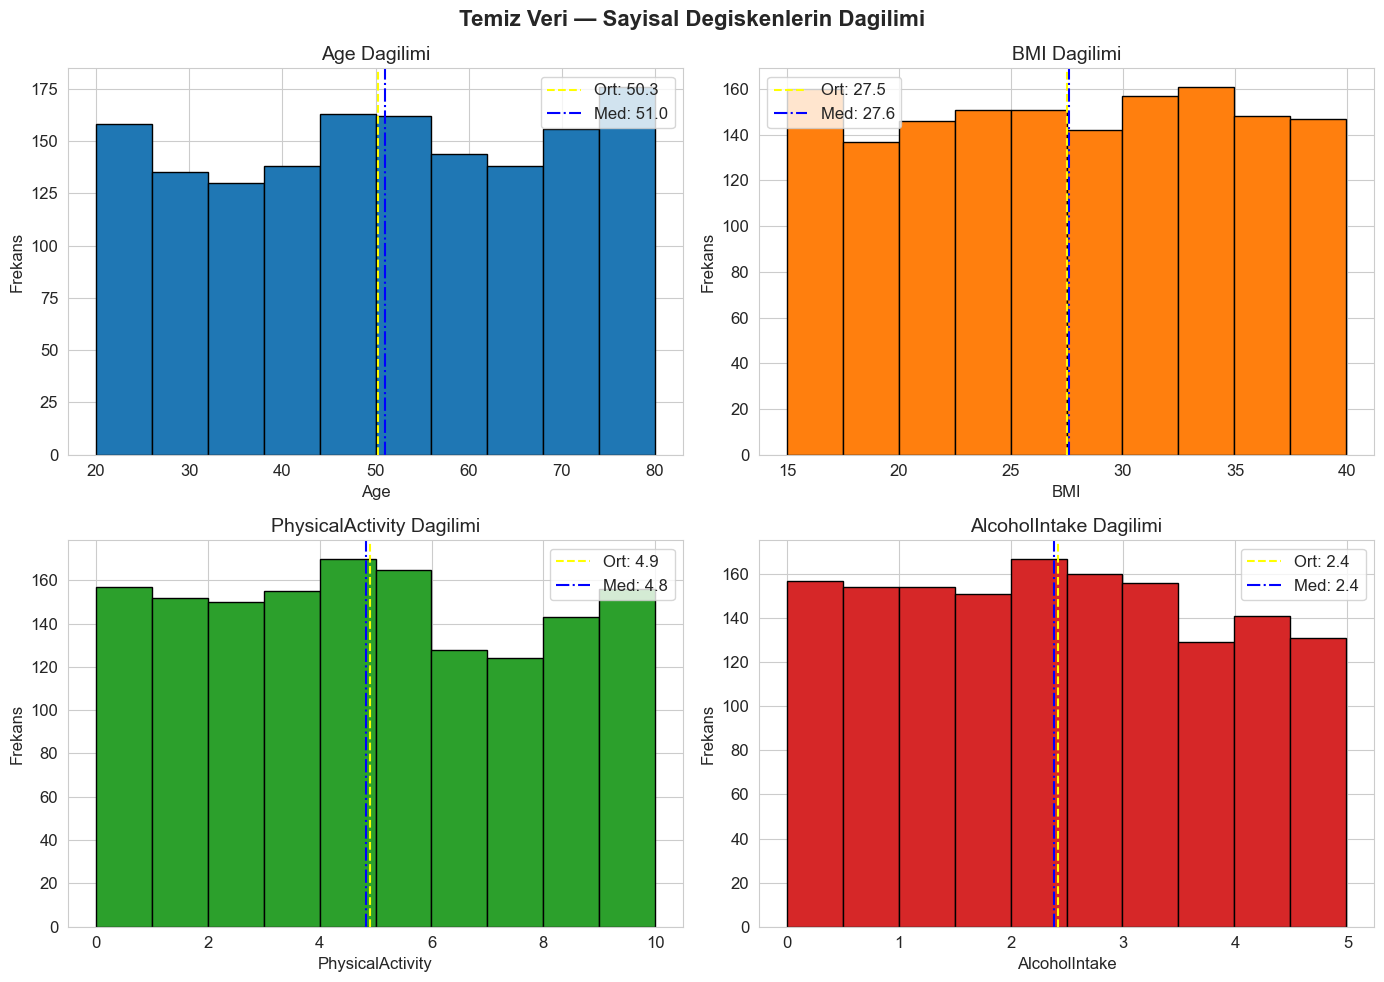

In [199]:
# Sayisal degiskenlerin histogram dagilimi
sayisal_sutunlar = ['Age', 'BMI', 'PhysicalActivity', 'AlcoholIntake']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Temiz Veri — Sayisal Degiskenlerin Dagilimi', fontsize=16, fontweight='bold')

renkler = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
for i, col in enumerate(sayisal_sutunlar):
    ax = axes[i // 2][i % 2]
    ax.hist(df_orijinal[col], color=renkler[i], edgecolor='black')
    ax.set_title(f'{col} Dagilimi')
    ax.set_xlabel(col)
    ax.set_ylabel('Frekans')
    # Ortalama cizgisi
    ax.axvline(df_orijinal[col].mean(), color='yellow', linestyle='--', label=f'Ort: {df_orijinal[col].mean():.1f}')
    ax.axvline(df_orijinal[col].median(), color='blue', linestyle='-.', label=f'Med: {df_orijinal[col].median():.1f}')
    ax.legend() #label gosterir

plt.tight_layout()  #grafikleriin yazilari birbirne girmesin
plt.show()

### 2.2 Kategorik Değişkenlerin Dağılımları

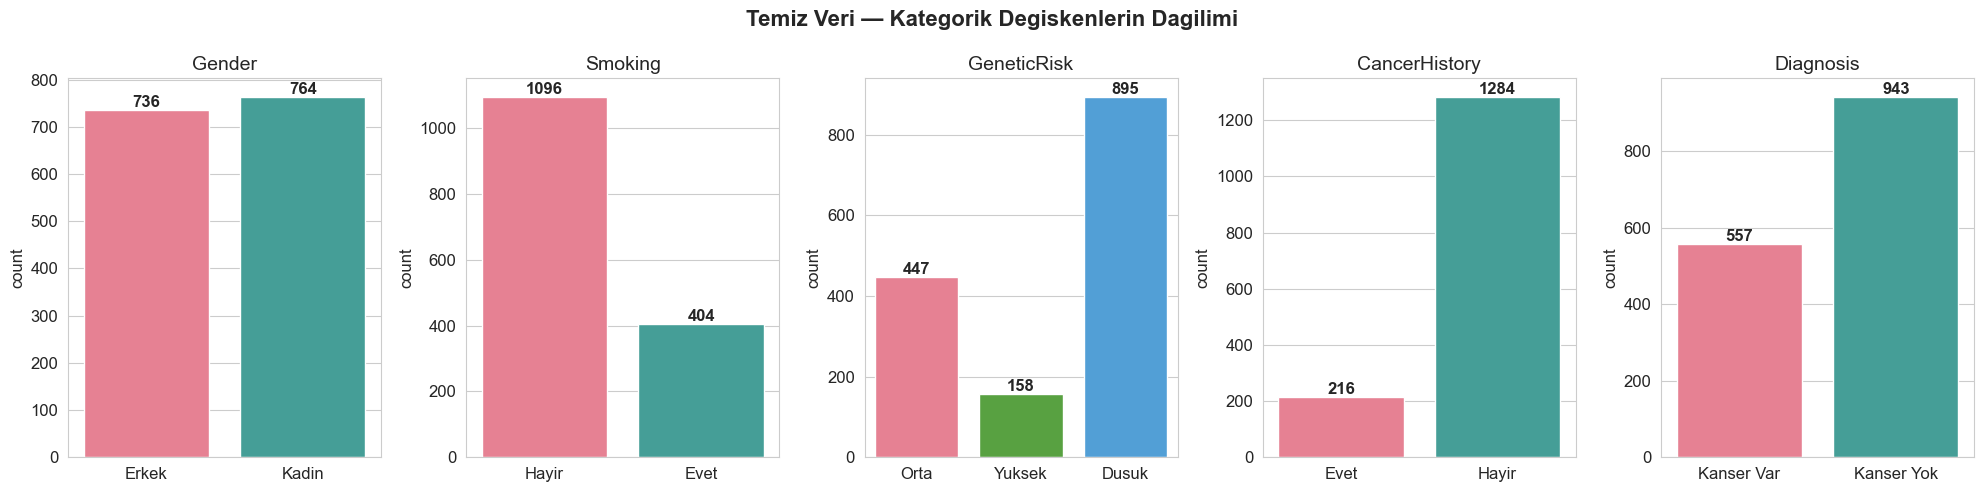

In [200]:
# Kategorik degiskenlerin countplot grafikleri
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
fig.suptitle('Temiz Veri — Kategorik Degiskenlerin Dagilimi', fontsize=16, fontweight='bold')

etiketler = {
    'Gender': {0: 'Kadin', 1: 'Erkek'},
    'Smoking': {0: 'Hayir', 1: 'Evet'},
    'GeneticRisk': {0: 'Dusuk', 1: 'Orta', 2: 'Yuksek'},
    'CancerHistory': {0: 'Hayir', 1: 'Evet'},
    'Diagnosis': {0: 'Kanser Yok', 1: 'Kanser Var'}
}

for i, col in enumerate(kategorik_sutunlar):
    temp = df_orijinal[col].map(etiketler[col])
    sns.countplot(x=temp, ax=axes[i], palette='husl')
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    # Barlarin uzerine sayi yaz
    for p in axes[i].patches:
        axes[i].annotate(f'{int(p.get_height())}', 
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

### 2.4 Boxplot ile Aykırı Değer Kontrolü

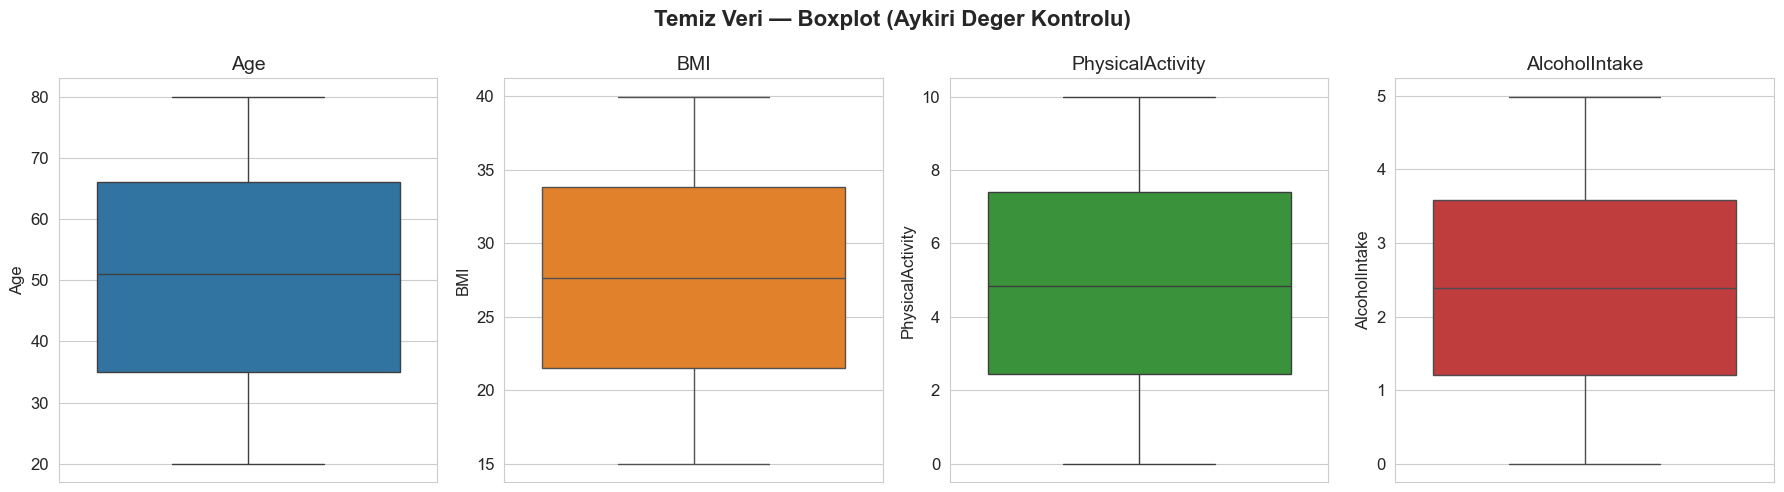

In [201]:
# Sayisal degiskenlerin boxplot grafikleri
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Temiz Veri — Boxplot (Aykiri Deger Kontrolu)', fontsize=16, fontweight='bold')

for i, col in enumerate(sayisal_sutunlar):
    sns.boxplot(y=df_orijinal[col], ax=axes[i], color=renkler[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

---

## 3. Veri Kirletme 

Bu bölümde, temiz veri seti kasıtlı olarak kirletilecektir. Amaç, veri biliminde karşılaşılan gerçek dünya sorunlarını simüle etmek ve veri temizleme sürecini göstermektir.

**Kirletme türleri:**
1. **Eksik veri (NaN):** Rastgele ~%10 eksik değer ekleme
2. **Aykırı değerler (Outliers):** Fizyolojik olarak imkansız değerler (~%10)
3. **Yanlış veri tipleri:** Sayısal alanlara metin (string) ekleme
4. **Tekrarlı kayıtlar (Duplicates):** ~50 satırın kopyalanması
5. **Geçersiz kategorik değerler:** Tanım dışı kategori kodları

In [202]:
# Tekrarlanabilirlik icin sabit seed
np.random.seed(42)

# Orijinal verinin kopyasini al
df_kirli = df_orijinal.copy()

# Kirletme oncesi kayit sayisi
print(f'Kirletme oncesi satir sayisi: {len(df_kirli)}')
print(f'Kirletme oncesi eksik deger: {df_kirli.isnull().sum().sum()}')

# ============================================
# 1. EKSIK VERI EKLEME (~%10)
# ============================================
eksik_sutunlar = df_kirli.columns  #['Age', 'BMI', 'PhysicalActivity', 'AlcoholIntake', 'Gender', 'Smoking']
eksik_sayisi = int(len(df_kirli) * 0.10)

for _ in range(eksik_sayisi):
    satir = np.random.randint(0, len(df_kirli))
    sutun = np.random.choice(eksik_sutunlar)
    df_kirli.at[satir, sutun] = np.nan

print(f'\n[1] Eksik veri eklendi: ~{eksik_sayisi} hucre NaN yapildi')

# ============================================
# 2. AYKIRI DEGER EKLEME (~%10)
# ============================================
n = len(df_kirli)
aykiri_sayisi = int(n * 0.10)  # ~150 aykiri deger

# Age: negatif ve 150+ yaslar
age_idx = np.random.choice(n, aykiri_sayisi // 4, replace=False)
yari=len(age_idx)//2

df_kirli.loc[age_idx[:len(age_idx)//2], 'Age'] = np.random.choice([-5, -10, -3, 155, 200, 180], yari)#ilk yari
df_kirli.loc[age_idx[len(age_idx)//2:], 'Age'] = np.random.uniform(150, 250, len(age_idx) - yari)#ikinci yari

# BMI: 0, negatif veya 80+ gibi imkansiz degerler
bmi_idx = np.random.choice(n, aykiri_sayisi // 4, replace=False)
df_kirli.loc[bmi_idx[:len(bmi_idx)//2], 'BMI'] = np.random.choice([-5, 0, 95, 120, 150], len(bmi_idx)//2)
df_kirli.loc[bmi_idx[len(bmi_idx)//2:], 'BMI'] = np.random.uniform(80, 200, len(bmi_idx) - len(bmi_idx)//2)

# AlcoholIntake: negatif veya 50+ degerler
alc_idx = np.random.choice(n, aykiri_sayisi // 4, replace=False)
df_kirli.loc[alc_idx, 'AlcoholIntake'] = np.random.choice([-10, -5, 50, 80, 100], len(alc_idx))

# PhysicalActivity: negatif veya 50+ degerler
pa_idx = np.random.choice(n, aykiri_sayisi // 4, replace=False)
df_kirli.loc[pa_idx, 'PhysicalActivity'] = np.random.choice([-8, -15, 60, 80, 100], len(pa_idx))

print(f'[2] Aykiri deger eklendi: ~{aykiri_sayisi} hucre bozuldu')

# ============================================
# 3. YANLIS VERI TIPI EKLEME
# ============================================
# Bazi sayisal alanlara string degerler yerlestir
df_kirli = df_kirli.astype(object)  # Tum sutunlari object yap (string ekleyebilmek icin)

yanlis_tip_sayisi = 30
yanlis_degerler = ['bilinmiyor', 'N/A', '?', 'yok', 'hatali', '--', 'null']

for _ in range(yanlis_tip_sayisi):
    satir = np.random.randint(0, len(df_kirli))
    sutun = np.random.choice(['Age', 'BMI', 'PhysicalActivity', 'AlcoholIntake'])
    df_kirli.at[satir, sutun] = np.random.choice(yanlis_degerler)

print(f'[3] Yanlis veri tipi eklendi: {yanlis_tip_sayisi} hucreye string deger yerlestirildi')



Kirletme oncesi satir sayisi: 1500
Kirletme oncesi eksik deger: 0

[1] Eksik veri eklendi: ~150 hucre NaN yapildi
[2] Aykiri deger eklendi: ~150 hucre bozuldu
[3] Yanlis veri tipi eklendi: 30 hucreye string deger yerlestirildi


---

## 3. kirli veriyi inceleme
 

In [203]:
# Kirli verinin genel durumu
print('=== KİRLİ VERİ — GENEL DURUM ===')
print(f'\nSatir sayisi: {len(df_kirli)}')

print(f'\n--- Eksik Degerler ---')
print(df_kirli.isnull().sum())
print(f'\nToplam eksik: {df_kirli.isnull().sum().sum()}')

print(f'\n--- Veri Tipleri ---')
print(df_kirli.dtypes)

=== KİRLİ VERİ — GENEL DURUM ===

Satir sayisi: 1500

--- Eksik Degerler ---
Age                 17
Gender              15
BMI                 18
Smoking             17
GeneticRisk         13
PhysicalActivity    13
AlcoholIntake       18
CancerHistory       18
Diagnosis           18
dtype: int64

Toplam eksik: 147

--- Veri Tipleri ---
Age                 object
Gender              object
BMI                 object
Smoking             object
GeneticRisk         object
PhysicalActivity    object
AlcoholIntake       object
CancerHistory       object
Diagnosis           object
dtype: object


### 3.1 Kirli Veri Görselleştirmeleri

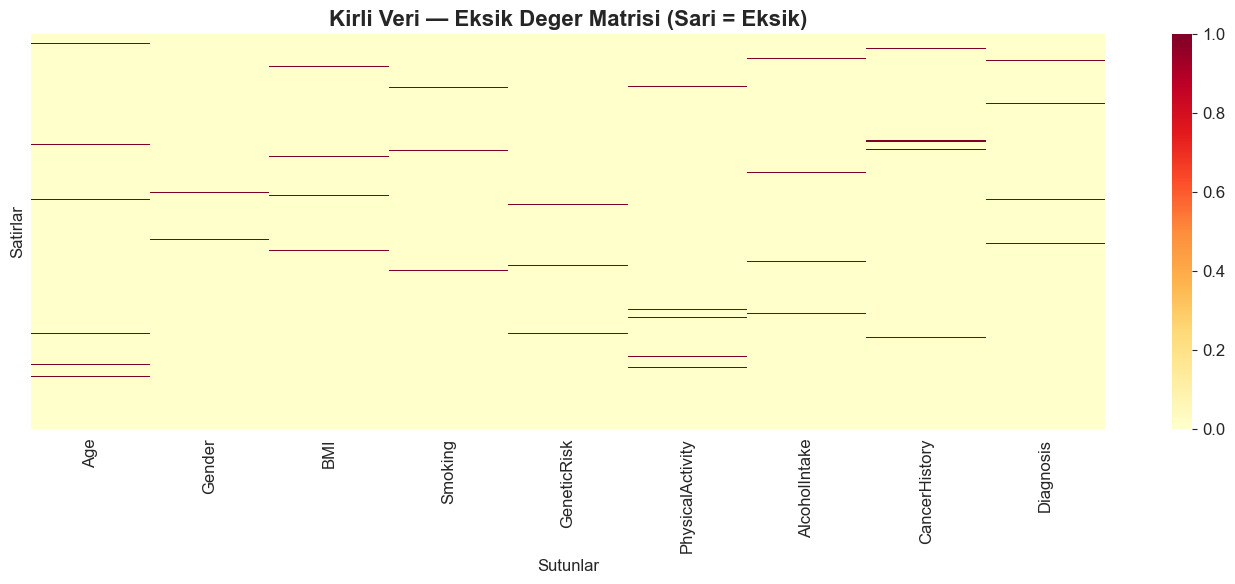

In [204]:
# Eksik veri matrisi (heatmap)
plt.figure(figsize=(14, 6))
sns.heatmap(df_kirli.isnull(), cbar=True, yticklabels=False, cmap='YlOrRd')
plt.title('Kirli Veri — Eksik Deger Matrisi (Sari = Eksik)', fontsize=16, fontweight='bold')
plt.xlabel('Sutunlar')
plt.ylabel('Satirlar')
plt.tight_layout()
plt.show()

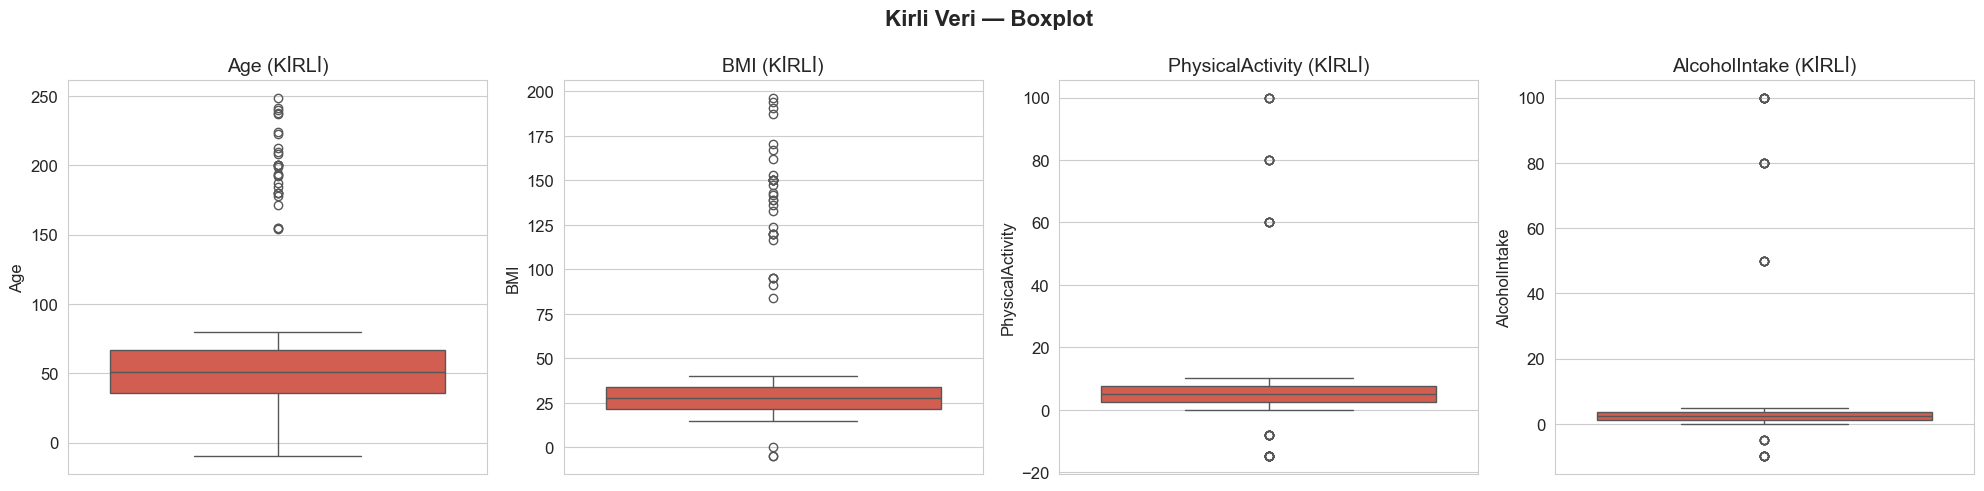

In [205]:
# Kirli veri - aykiri degerleri gormek icin boxplot - boxplot nan ile calsir hatali verileri nan yapiyo
# Once sayisal sutunlari numeric'e cevirelim (hatali degerleri NaN yaparak)
df_kirli_sayisal = df_kirli.copy()
for col in sayisal_sutunlar:
    df_kirli_sayisal[col] = pd.to_numeric(df_kirli_sayisal[col], errors='coerce')

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Kirli Veri — Boxplot ', fontsize=16, fontweight='bold')

for i, col in enumerate(sayisal_sutunlar):

    sns.boxplot(df_kirli_sayisal[col], ax=axes[i], color='#e74c3c')
    axes[i].set_title(f'{col} (KİRLİ)')

plt.tight_layout()
plt.show()

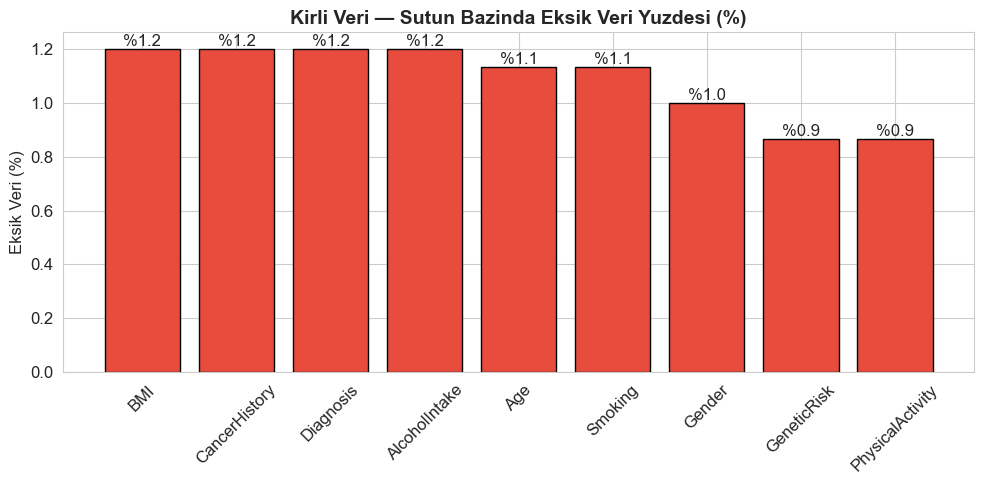

In [206]:
# Sutun bazinda eksik veri yuzdesi bar grafigi
eksik_yuzde = (df_kirli.isnull().sum() / len(df_kirli) * 100).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
bars = plt.bar(eksik_yuzde.index, eksik_yuzde.values, color='#e74c3c', edgecolor='black')
plt.title('Kirli Veri — Sutun Bazinda Eksik Veri Yuzdesi (%)', fontsize=14, fontweight='bold')
plt.ylabel('Eksik Veri (%)')
plt.xticks(rotation=45)

# Barlarin uzerine yuzde yaz
for bar, val in zip(bars, eksik_yuzde.values):
    if val > 0:
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() ,
                f'%{val:.1f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

---

## 4. Veri Temizleme ve Ön İşleme

Bu bölümde kirletilmiş veri sistematik olarak temizlenecektir:
1. Yanlış veri tiplerinin düzeltilmesi
2. Eksik değerlerin doldurulması
3. Aykırı değerlerin tespiti ve düzeltilmesi

In [207]:

df_temiz = df_kirli.copy()

print('=== ADIM 1: YANLIS VERİ TİPLERİNİ DÜZELT ===')

for col in df_temiz.columns:
    df_temiz[col] = pd.to_numeric(df_temiz[col], errors='coerce')

print('\nTum sutunlar sayisal tipe yanlis veriler NaN degere donusturuldu.')
print(df_temiz.dtypes)

=== ADIM 1: YANLIS VERİ TİPLERİNİ DÜZELT ===

Tum sutunlar sayisal tipe yanlis veriler NaN degere donusturuldu.
Age                 float64
Gender              float64
BMI                 float64
Smoking             float64
GeneticRisk         float64
PhysicalActivity    float64
AlcoholIntake       float64
CancerHistory       float64
Diagnosis           float64
dtype: object


In [208]:
print('=== ADIM 2: AYKIRI DEĞERLERİ TESPİT ET VE DÜZELT ===')
print()

# -------------------------------------------------------
# Adim 2a: Fiziksel olarak IMKANSIZ degerleri kaldir (sert temizlik)
# -------------------------------------------------------
print('--- Adim 2a: Fiziksel olarak imkansiz degerleri kaldir (sert temizlik) ---')

fiziksel_sinirlar = {
    'Age': (18, 120),
    'BMI': (10, 60),
    'PhysicalActivity': (0, 10),
    'AlcoholIntake': (0, 5)
}

onceki_satir = len(df_temiz)

for col, (alt, ust) in fiziksel_sinirlar.items():
    onceki = len(df_temiz)
    # NaN olmayan satirlarda fiziksel sinir disi olanlari kaldir
    mask = df_temiz[col].notna()
    df_temiz = df_temiz[~mask | ((df_temiz[col] >= alt) & (df_temiz[col] <= ust))]
    silinen = onceki - len(df_temiz)
    if silinen > 0:
        print(f'  {col}: {silinen} satir silindi (Fiziksel sinir: [{alt}, {ust}])')

toplam_silinen = onceki_satir - len(df_temiz)
print(f'\n  Toplam silinen satir: {toplam_silinen}')
print(f'  Kalan satir sayisi: {len(df_temiz)}')

# Index'i sifirla
df_temiz = df_temiz.reset_index(drop=True)

# -------------------------------------------------------
# Adim 2b: Kalan hafif aykiri degerleri IQR ile tespit et (yumusak temizlik)
# -------------------------------------------------------
print('\n--- Adim 2b: Kalan hafif aykiri degerleri IQR ile tespit et (yumusak temizlik) ---')

def aykiri_deger_nan(df, sutun):
    """IQR yontemiyle hafif aykiri degerleri tespit edip NaN ile degistirme."""
    Q1 = df[sutun].quantile(0.25)
    Q3 = df[sutun].quantile(0.75)
    IQR = Q3 - Q1
    
    iqr_alt = Q1 - 1.5 * IQR
    iqr_ust = Q3 + 1.5 * IQR
    
    aykiri_mask = (df[sutun] < iqr_alt) | (df[sutun] > iqr_ust)
    aykiri_sayisi = aykiri_mask.sum()
    
    # Hafif aykiri degerleri NaN ile degistir (Adim 3'te medyan ile doldurulacak)
    df.loc[aykiri_mask, sutun] = np.nan
    
    return aykiri_sayisi, iqr_alt, iqr_ust

sayisal_sutunlar = ['Age', 'BMI', 'PhysicalActivity', 'AlcoholIntake']

aykiri_bilgi = {}
for col in sayisal_sutunlar:
    sayi, alt_s, ust_s = aykiri_deger_nan(df_temiz, col)
    aykiri_bilgi[col] = sayi
    if sayi > 0:
        print(f'  {col}: {sayi} hafif aykiri deger NaN ile degistirildi (IQR: [{alt_s:.2f}, {ust_s:.2f}])')

toplam_iqr = sum(aykiri_bilgi.values())
if toplam_iqr > 0:
    print(f'\n  Toplam NaN ile degistirilen: {toplam_iqr}')
else:
    print('\n  IQR sonrasi ek aykiri deger bulunamadi.')


=== ADIM 2: AYKIRI DEĞERLERİ TESPİT ET VE DÜZELT ===

--- Adim 2a: Fiziksel olarak imkansiz degerleri kaldir (sert temizlik) ---
  Age: 37 satir silindi (Fiziksel sinir: [18, 120])
  BMI: 33 satir silindi (Fiziksel sinir: [10, 60])
  PhysicalActivity: 36 satir silindi (Fiziksel sinir: [0, 10])
  AlcoholIntake: 37 satir silindi (Fiziksel sinir: [0, 5])

  Toplam silinen satir: 143
  Kalan satir sayisi: 1357

--- Adim 2b: Kalan hafif aykiri degerleri IQR ile tespit et (yumusak temizlik) ---

  IQR sonrasi ek aykiri deger bulunamadi.


In [209]:
print('=== ADIM 3: EKSİK DEĞERLERİ DOLDUR ===')
print('\nDoldurma oncesi eksik degerler:')
print(df_temiz.isnull().sum())

# Sayisal degiskenler: medyan ile doldur
for col in ['Age', 'BMI', 'PhysicalActivity', 'AlcoholIntake']:
    medyan = df_temiz[col].median()
    eksik = df_temiz[col].isnull().sum()
    df_temiz[col].fillna(medyan, inplace=True)
    print(f'  {col}: {eksik} eksik deger medyan ({medyan:.2f}) ile dolduruldu')

# Kategorik degiskenler: mod (en sık deger) ile doldur
for col in ['Gender', 'Smoking', 'GeneticRisk', 'CancerHistory', 'Diagnosis']:
    mod = df_temiz[col].mode()[0]
    eksik = df_temiz[col].isnull().sum()
    df_temiz[col].fillna(mod, inplace=True)
    if eksik > 0:
        print(f'  {col}: {eksik} eksik deger mod ({mod:.0f}) ile dolduruldu')



print(f'\n=== DOLDURMA SONRASI KONTROL ===')
print(f'Kalan eksik deger: {df_temiz.isnull().sum().sum()}')
print(f'Son satir sayisi: {len(df_temiz)}')

=== ADIM 3: EKSİK DEĞERLERİ DOLDUR ===

Doldurma oncesi eksik degerler:
Age                 24
Gender              14
BMI                 24
Smoking             15
GeneticRisk         12
PhysicalActivity    16
AlcoholIntake       26
CancerHistory       14
Diagnosis           18
dtype: int64
  Age: 24 eksik deger medyan (51.00) ile dolduruldu
  BMI: 24 eksik deger medyan (27.42) ile dolduruldu
  PhysicalActivity: 16 eksik deger medyan (4.86) ile dolduruldu
  AlcoholIntake: 26 eksik deger medyan (2.32) ile dolduruldu
  Gender: 14 eksik deger mod (0) ile dolduruldu
  Smoking: 15 eksik deger mod (0) ile dolduruldu
  GeneticRisk: 12 eksik deger mod (0) ile dolduruldu
  CancerHistory: 14 eksik deger mod (0) ile dolduruldu
  Diagnosis: 18 eksik deger mod (0) ile dolduruldu

=== DOLDURMA SONRASI KONTROL ===
Kalan eksik deger: 0
Son satir sayisi: 1357


In [210]:
# Temizleme sonrasi genel kontrol
print('=== TEMİZLENMİŞ VERİ — SON DURUM ===')
print(f'Satir sayisi: {len(df_temiz)}')
print(f'Sutun sayisi: {df_temiz.shape[1]}')
print(f'Eksik deger: {df_temiz.isnull().sum().sum()}')
print(f'\nVeri tipleri:')
print(df_temiz.dtypes)
print(f'\nTanimlayici istatistikler:')
df_temiz.describe().round(2)

=== TEMİZLENMİŞ VERİ — SON DURUM ===
Satir sayisi: 1357
Sutun sayisi: 9
Eksik deger: 0

Veri tipleri:
Age                 float64
Gender              float64
BMI                 float64
Smoking             float64
GeneticRisk         float64
PhysicalActivity    float64
AlcoholIntake       float64
CancerHistory       float64
Diagnosis           float64
dtype: object

Tanimlayici istatistikler:


,Age,Gender,BMI,Smoking,GeneticRisk,PhysicalActivity,AlcoholIntake,CancerHistory,Diagnosis
count,1357.00,1357.00,1357.00,1357.00,1357.00,1357.00,1357.00,1357.00,1357.00
mean,50.64,0.49,27.43,0.27,0.52,4.93,2.40,0.14,0.37
std,17.50,0.50,7.23,0.44,0.68,2.86,1.41,0.35,0.48
min,20.00,0.00,15.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,36.00,0.00,21.47,0.00,0.00,2.47,1.22,0.00,0.00
50%,51.00,0.00,27.42,0.00,0.00,4.86,2.32,0.00,0.00
75%,66.00,1.00,33.69,1.00,1.00,7.43,3.55,0.00,1.00
max,80.00,1.00,39.96,1.00,2.00,9.99,4.99,1.00,1.00


### 4.1 Temizleme Öncesi / Sonrası Karşılaştırma

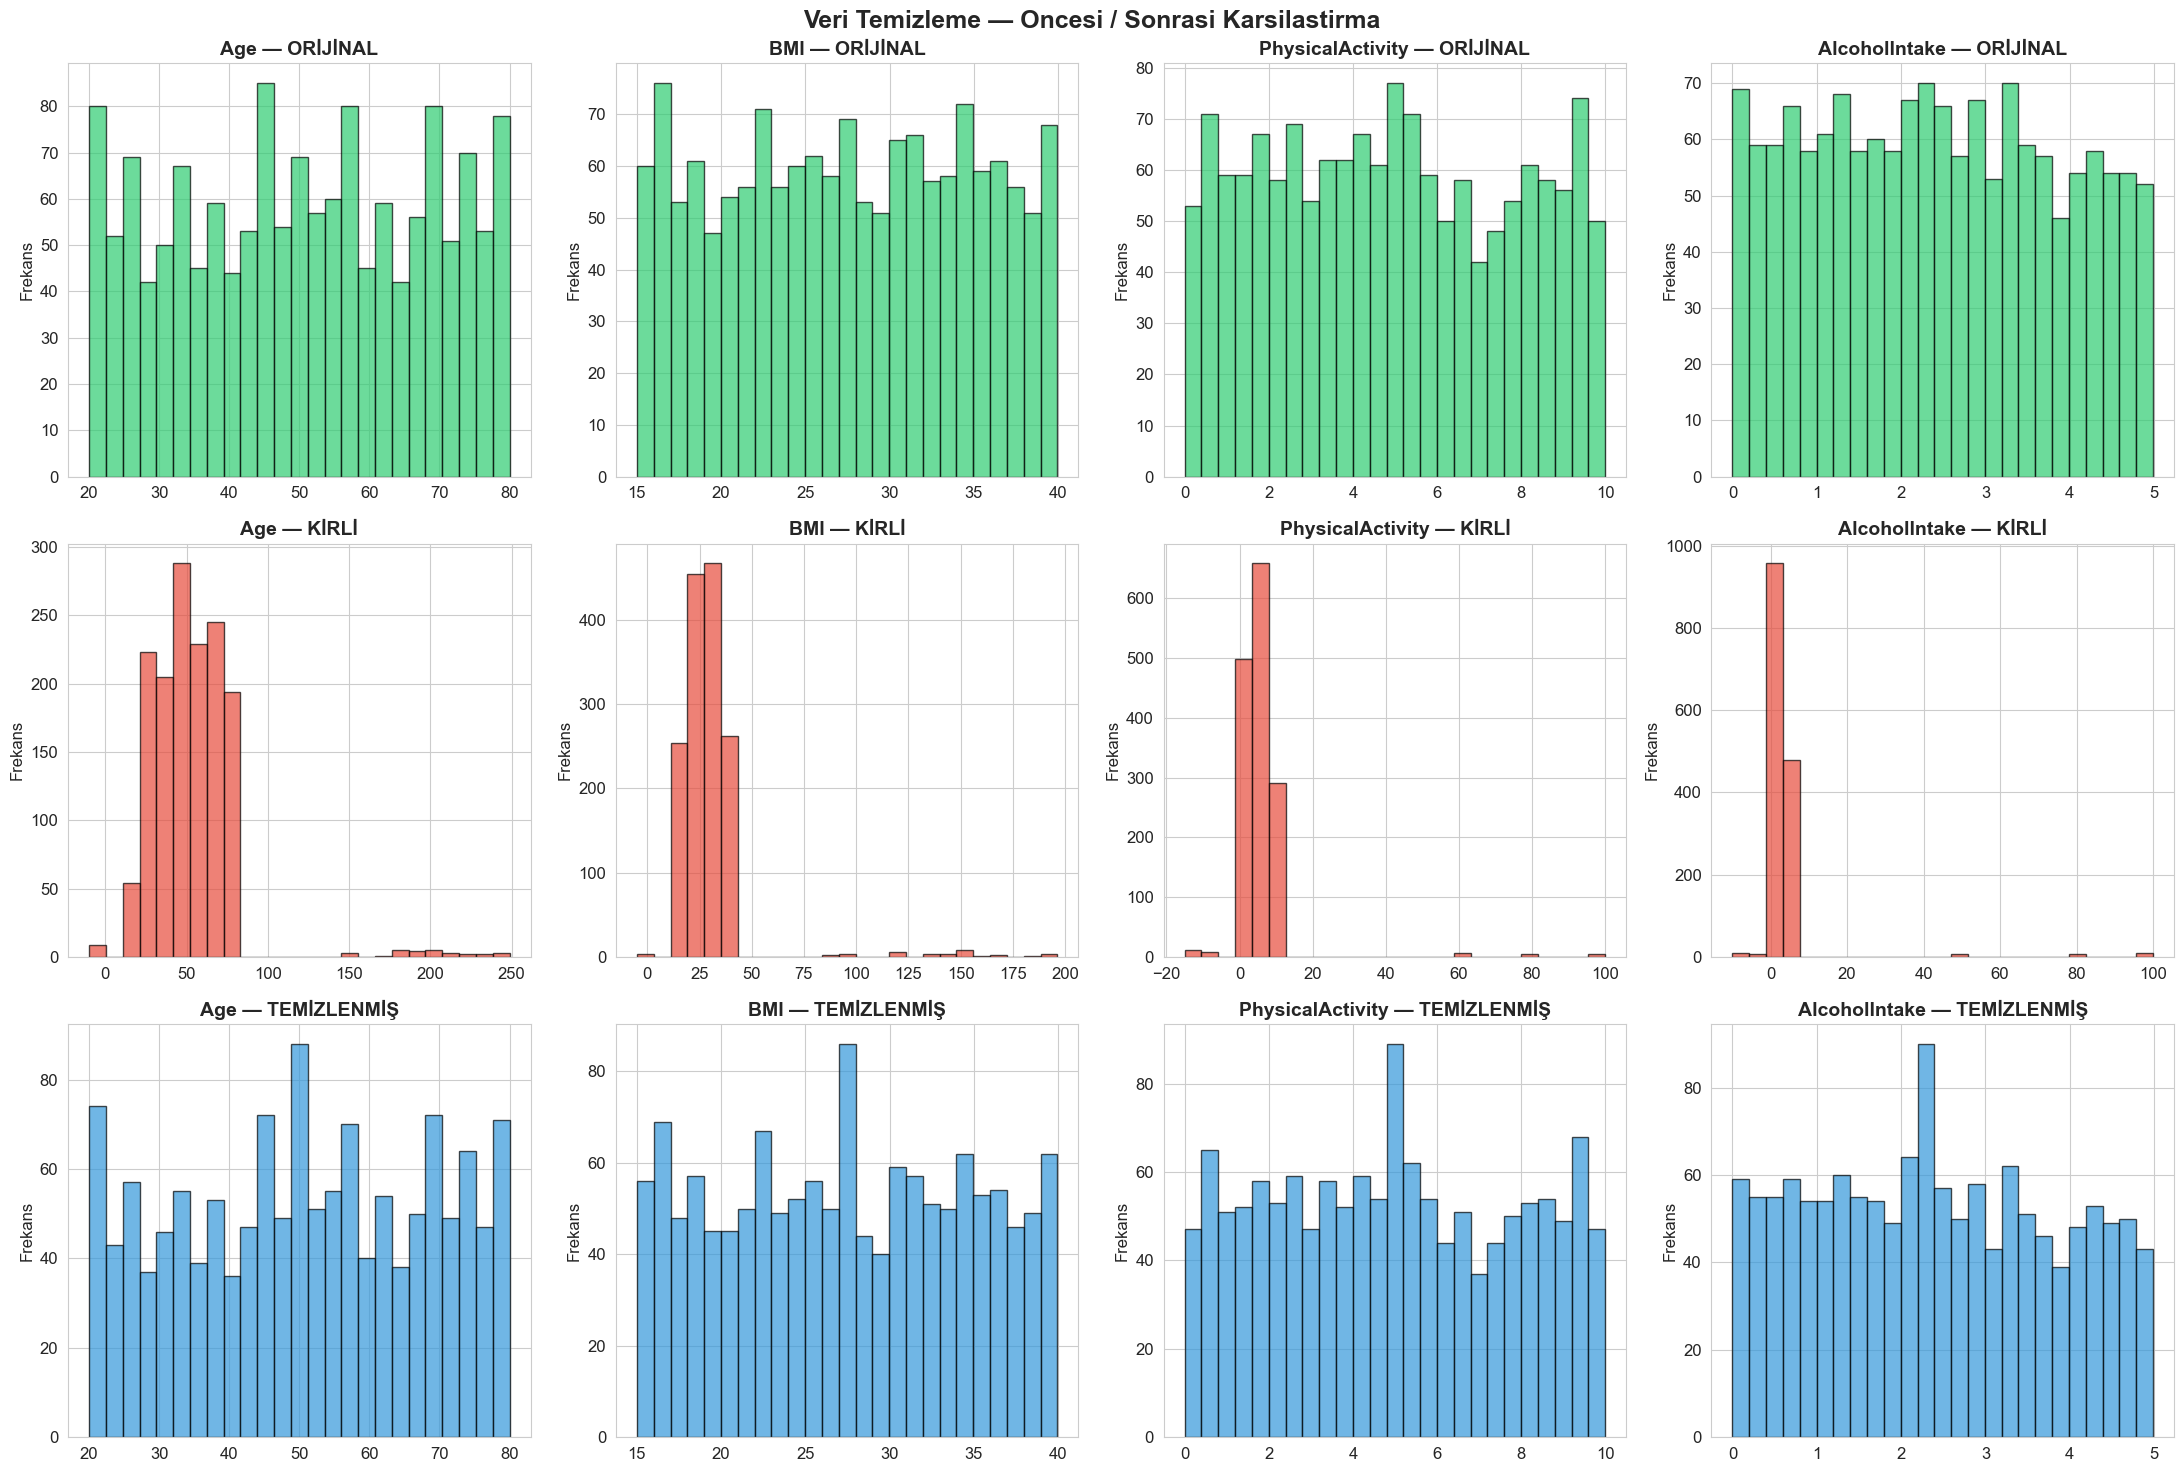

In [211]:
# ONCESI / SONRASI KARSILASTIRMA — Sayisal degiskenler
fig, axes = plt.subplots(3, 4, figsize=(22, 15))
fig.suptitle('Veri Temizleme — Oncesi / Sonrasi Karsilastirma', fontsize=18, fontweight='bold')

for i, col in enumerate(sayisal_sutunlar):
    # Orijinal (temiz)
    axes[0][i].hist(df_orijinal[col], bins=25, color='#2ecc71', edgecolor='black', alpha=0.7)
    axes[0][i].set_title(f'{col} — ORİJİNAL', fontweight='bold')
    axes[0][i].set_ylabel('Frekans')
    
    # Kirli
    kirli_col = pd.to_numeric(df_kirli[col], errors='coerce')
    axes[1][i].hist(kirli_col.dropna(), bins=25, color='#e74c3c', edgecolor='black', alpha=0.7)
    axes[1][i].set_title(f'{col} — KİRLİ', fontweight='bold')
    axes[1][i].set_ylabel('Frekans')
    
    # Temizlenmis
    axes[2][i].hist(df_temiz[col], bins=25, color='#3498db', edgecolor='black', alpha=0.7)
    axes[2][i].set_title(f'{col} — TEMİZLENMİŞ', fontweight='bold')
    axes[2][i].set_ylabel('Frekans')

plt.tight_layout()
plt.show()

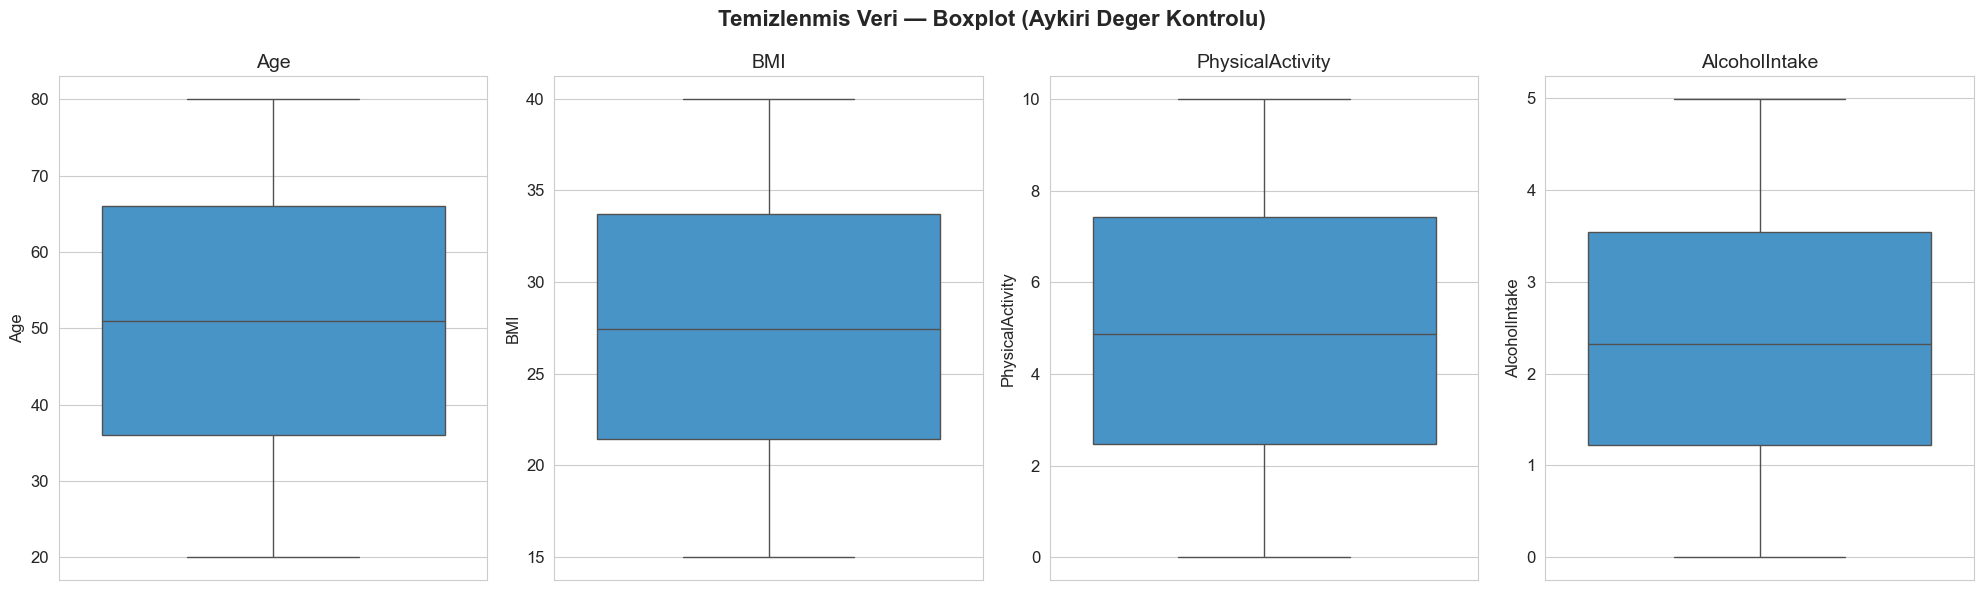

==> Temizleme sonrasi aykiri degerler basariyla giderilmistir.


In [212]:
# Boxplot karsilastirmasi — 3 durum yan yana
fig, axes = plt.subplots(1, 4, figsize=(20, 6))
fig.suptitle('Temizlenmis Veri — Boxplot (Aykiri Deger Kontrolu)', fontsize=16, fontweight='bold')

for i, col in enumerate(sayisal_sutunlar):
    sns.boxplot(y=df_temiz[col], ax=axes[i], color='#3498db')
    axes[i].set_title(col)

plt.tight_layout()
plt.show()
print('==> Temizleme sonrasi aykiri degerler basariyla giderilmistir.')

In [ ]:
# Temizleme oncesi/sonrasi ozet tablo
print('=' * 60)
print('TEMİZLEME ÖZETİ')
print('=' * 60)
print(f'{"Metrik":<30} {"Kirli":>10} {"Temiz":>10}')
print('-' * 60)
print(f'{"Satir sayisi":<30} {len(df_kirli):>10} {len(df_temiz):>10}')
print(f'{"Toplam eksik deger":<30} {df_kirli.isnull().sum().sum():>10} {df_temiz.isnull().sum().sum():>10}')
print('=' * 60)

TEMİZLEME ÖZETİ
Metrik                              Kirli      Temiz
------------------------------------------------------------
Satir sayisi                         1500       1357
Toplam eksik deger                    147          0
Duplike satir                           0          0


---

## 5. İstatistiksel Analizler ve Hipotez Testleri

Bu bölümde temizlenmiş veri üzerinde kapsamlı istatistiksel analizler gerçekleştirilecektir.

### 5.1 Tanımlayıcı İstatistikler

In [214]:
df_temiz.describe().round(2)

,Age,Gender,BMI,Smoking,GeneticRisk,PhysicalActivity,AlcoholIntake,CancerHistory,Diagnosis
count,1357.00,1357.00,1357.00,1357.00,1357.00,1357.00,1357.00,1357.00,1357.00
mean,50.64,0.49,27.43,0.27,0.52,4.93,2.40,0.14,0.37
std,17.50,0.50,7.23,0.44,0.68,2.86,1.41,0.35,0.48
min,20.00,0.00,15.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,36.00,0.00,21.47,0.00,0.00,2.47,1.22,0.00,0.00
50%,51.00,0.00,27.42,0.00,0.00,4.86,2.32,0.00,0.00
75%,66.00,1.00,33.69,1.00,1.00,7.43,3.55,0.00,1.00
max,80.00,1.00,39.96,1.00,2.00,9.99,4.99,1.00,1.00


### 5.2 Normallik Testleri

Hipotez testlerinde hangi yöntemin kullanılacağını belirlemek için sayısal değişkenlerin normal dağılıma uygunluğu test edilmelidir.

In [215]:
# Normallik testleri (Shapiro-Wilk ve Kolmogorov-Smirnov)
print('=== NORMALLİK TESTLERİ ===')
print(f'Anlamlilik duzeyi: alpha = 0.05')
print(f'H0: Veri normal dagilima uygundur')
print(f'H1: Veri normal dagilima uygun degildir')
print()

alpha = 0.05
normallik_sonuc = []

for col in sayisal_sutunlar:
    # Shapiro-Wilk (n<5000 icin uygundur)
    if len(df_temiz[col]) > 5000:
        orneklem = df_temiz[col].sample(5000, random_state=42)
    else:
        orneklem = df_temiz[col]
    
    shapiro_stat, shapiro_p = shapiro(orneklem)
    ks_stat, ks_p = kstest(df_temiz[col], 'norm', 
                           args=(df_temiz[col].mean(), df_temiz[col].std()))
    
    shapiro_sonuc = 'Normal' if shapiro_p > alpha else 'Normal Degil'
    ks_sonuc = 'Normal' if ks_p > alpha else 'Normal Degil'
    
    normallik_sonuc.append({
        'Degisken': col,
        'Shapiro-Wilk Stat': round(shapiro_stat, 4),
        'Shapiro p-value': round(shapiro_p, 4),
        'Shapiro Sonuc': shapiro_sonuc,
        'KS Stat': round(ks_stat, 4),
        'KS p-value': round(ks_p, 4),
        'KS Sonuc': ks_sonuc
    })

normallik_df = pd.DataFrame(normallik_sonuc)
print(normallik_df.to_string(index=False))

print('\nYorum: p-value < 0.05 ise H0 reddedilir, yani veri normal dagilima uygun degildir.')
print('Bu durumda parametrik olmayan testler (Mann-Whitney U vb.) tercih edilmelidir.')

=== NORMALLİK TESTLERİ ===
Anlamlilik duzeyi: alpha = 0.05
H0: Veri normal dagilima uygundur
H1: Veri normal dagilima uygun degildir

        Degisken  Shapiro-Wilk Stat  Shapiro p-value Shapiro Sonuc  KS Stat  KS p-value     KS Sonuc
             Age             0.9576              0.0  Normal Degil   0.0700      0.0000 Normal Degil
             BMI             0.9562              0.0  Normal Degil   0.0582      0.0002 Normal Degil
PhysicalActivity             0.9562              0.0  Normal Degil   0.0629      0.0000 Normal Degil
   AlcoholIntake             0.9601              0.0  Normal Degil   0.0557      0.0004 Normal Degil

Yorum: p-value < 0.05 ise H0 reddedilir, yani veri normal dagilima uygun degildir.
Bu durumda parametrik olmayan testler (Mann-Whitney U vb.) tercih edilmelidir.


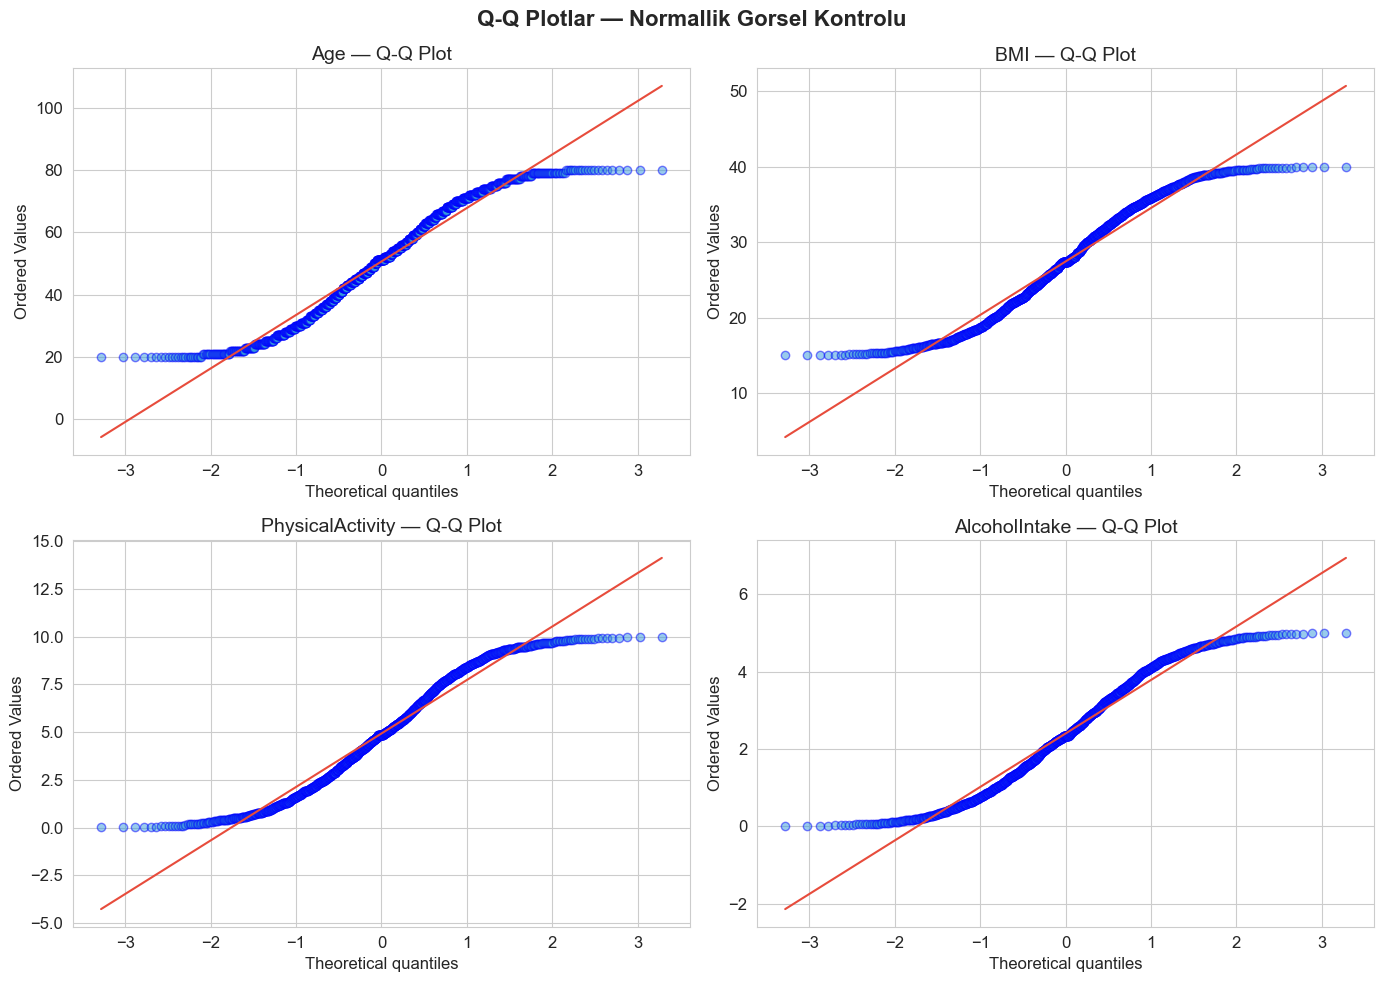

Yorum: Noktalar kirmizi cizgiye yakin ise veri normal dagilima yakindir.


In [216]:
# Q-Q Plotlar (Normallik gorsel kontrolu)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Q-Q Plotlar — Normallik Gorsel Kontrolu', fontsize=16, fontweight='bold')

for i, col in enumerate(sayisal_sutunlar):
    ax = axes[i // 2][i % 2]
    stats.probplot(df_temiz[col], dist='norm', plot=ax)
    ax.set_title(f'{col} — Q-Q Plot')
    ax.get_lines()[0].set_markerfacecolor('#3498db')
    ax.get_lines()[0].set_alpha(0.5)
    ax.get_lines()[1].set_color('#e74c3c')

plt.tight_layout()
plt.show()
print('Yorum: Noktalar kirmizi cizgiye yakin ise veri normal dagilima yakindir.')

### 5.3 Hipotez Testleri

Bu bölümde 4 farklı hipotez kurulmuş ve test edilmiştir.

---

#### HİPOTEZ 1: Sigara İçen ve İçmeyenlerin Kanser Teşhis Oranları

- **H₀ (Sıfır Hipotezi):** Sigara içen ve içmeyen gruplar arasında kanser teşhis oranı farkı yoktur (bağımsızdır).
- **H₁ (Alternatif Hipotez):** Sigara içen ve içmeyen gruplar arasında kanser teşhis oranı bakımından anlamlı fark vardır.
- **Test:** Ki-Kare (Chi-Square) Bağımsızlık Testi
- **α = 0.05**

HİPOTEZ 1: Sigara Kullanimi ve Kanser Teshisi Arasindaki Iliski

Capraz Tablo:
                Kanser Yok  Kanser Var  Toplam
Sigara Icmiyor         689         304     993
Sigara Iciyor          168         196     364
Toplam                 857         500    1357

--- Ki-Kare Test Sonuclari ---
Ki-Kare Istatistigi (X²): 60.7856
p-degeri: 0.000000
Serbestlik Derecesi (df): 1

Beklenen Frekanslar:
                Kanser Yok  Kanser Var
Sigara Icmiyor      627.12      365.88
Sigara Iciyor       229.88      134.12

--- KARAR (alpha = 0.05) ---
p-degeri (0.000000) < alpha (0.05)
=> H0 REDDEDİLDİ! Sigara kullanimi ile kanser teshisi arasinda
   istatistiksel olarak anlamli bir iliski VARDIR.


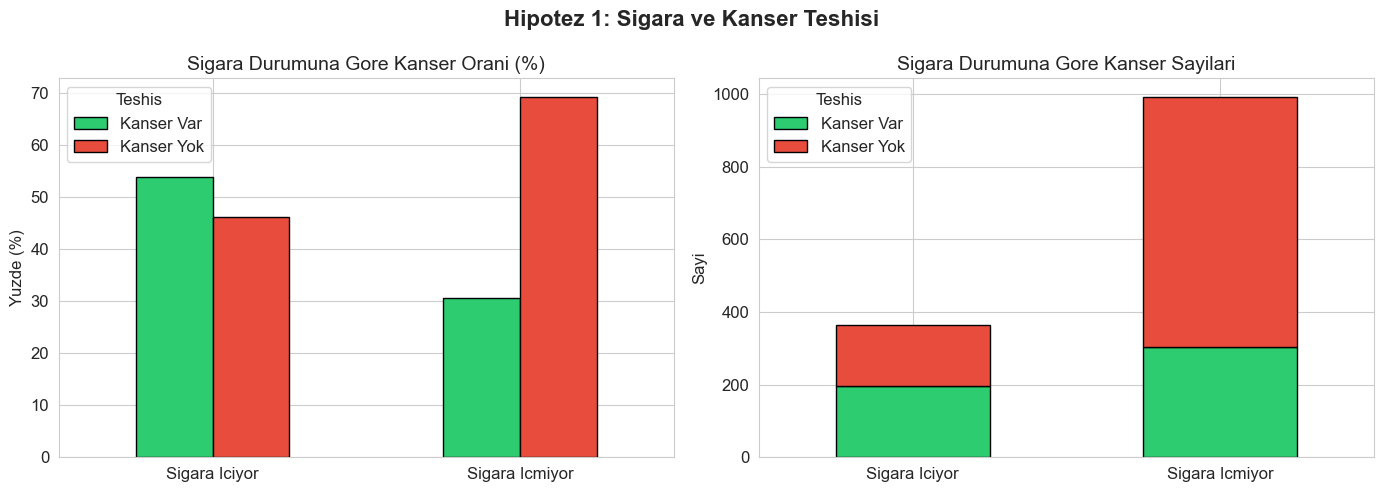

In [217]:
# HİPOTEZ 1: Sigara ve Kanser Teshisi — Ki-Kare Testi
print('=' * 70)
print('HİPOTEZ 1: Sigara Kullanimi ve Kanser Teshisi Arasindaki Iliski')
print('=' * 70)

# Capraz tablo (Contingency Table)
capraz_tablo1 = pd.crosstab(df_temiz['Smoking'], df_temiz['Diagnosis'],
                            margins=True, margins_name='Toplam')
capraz_tablo1.index = ['Sigara Icmiyor', 'Sigara Iciyor', 'Toplam']
capraz_tablo1.columns = ['Kanser Yok', 'Kanser Var', 'Toplam']
print('\nCapraz Tablo:')
print(capraz_tablo1)

# Ki-kare testi (marginsiz tablo ile)
ct1 = pd.crosstab(df_temiz['Smoking'], df_temiz['Diagnosis'])
chi2, p_value, dof, expected = chi2_contingency(ct1)

print(f'\n--- Ki-Kare Test Sonuclari ---')
print(f'Ki-Kare Istatistigi (X²): {chi2:.4f}')
print(f'p-degeri: {p_value:.6f}')
print(f'Serbestlik Derecesi (df): {dof}')

# Beklenen frekanslar
print(f'\nBeklenen Frekanslar:')
print(pd.DataFrame(expected.round(2), 
                   index=['Sigara Icmiyor', 'Sigara Iciyor'],
                   columns=['Kanser Yok', 'Kanser Var']))

# Karar
alpha = 0.05
print(f'\n--- KARAR (alpha = {alpha}) ---')
if p_value < alpha:
    print(f'p-degeri ({p_value:.6f}) < alpha ({alpha})')
    print('=> H0 REDDEDİLDİ! Sigara kullanimi ile kanser teshisi arasinda')
    print('   istatistiksel olarak anlamli bir iliski VARDIR.')
else:
    print(f'p-degeri ({p_value:.6f}) >= alpha ({alpha})')
    print('=> H0 REDDEDİLEMEZ! Sigara kullanimi ile kanser teshisi arasinda')
    print('   istatistiksel olarak anlamli bir iliski bulunamadi.')

# Gorsellessirme
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Hipotez 1: Sigara ve Kanser Teshisi', fontsize=16, fontweight='bold')

# Grouped barplot
ct1_pct = pd.crosstab(df_temiz['Smoking'].map({0: 'Sigara Icmiyor', 1: 'Sigara Iciyor'}), 
                       df_temiz['Diagnosis'].map({0: 'Kanser Yok', 1: 'Kanser Var'}),
                       normalize='index') * 100
ct1_pct.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0].set_title('Sigara Durumuna Gore Kanser Orani (%)')
axes[0].set_ylabel('Yuzde (%)')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Teshis')

# Stacked barplot
ct1_abs = pd.crosstab(df_temiz['Smoking'].map({0: 'Sigara Icmiyor', 1: 'Sigara Iciyor'}), 
                       df_temiz['Diagnosis'].map({0: 'Kanser Yok', 1: 'Kanser Var'}))
ct1_abs.plot(kind='bar', stacked=True, ax=axes[1], color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[1].set_title('Sigara Durumuna Gore Kanser Sayilari')
axes[1].set_ylabel('Sayi')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Teshis')

plt.tight_layout()
plt.show()

#### HİPOTEZ 2: Kanser Teşhisi ve Yaş İlişkisi

- **H₀ (Sıfır Hipotezi):** Kanser teşhisi olan ve olmayan grupların yaş ortalamaları eşittir.
- **H₁ (Alternatif Hipotez):** İki grubun yaş ortalamaları arasında anlamlı fark vardır.
- **Test:** Normallik durumuna göre → Bağımsız Örneklem T-Testi veya Mann-Whitney U Testi
- **α = 0.05**

HİPOTEZ 2: Kanser Teshisi Konan ve Konmayan Kisilerin Yas Farki

Grup Istatistikleri:
  Kanser Yok (n=857): Ort=47.99, Med=47.0, Std=17.48
  Kanser Var (n=500): Ort=55.19, Med=56.0, Std=16.59

Normallik Testi (Shapiro-Wilk):
  Kanser Yok p-degeri: 0.000000
  Kanser Var p-degeri: 0.000000

En az bir grup normal degil -> Mann-Whitney U Testi uygulanir
U-istatistigi: 162524.5000
p-degeri: 0.000000

--- KARAR (alpha = 0.05) ---
p-degeri (0.000000) < alpha (0.05)
=> H0 REDDEDİLDİ! Kanser teshisi olan ve olmayan gruplarin
   yas ortalamalari arasinda istatistiksel olarak anlamli fark VARDIR.


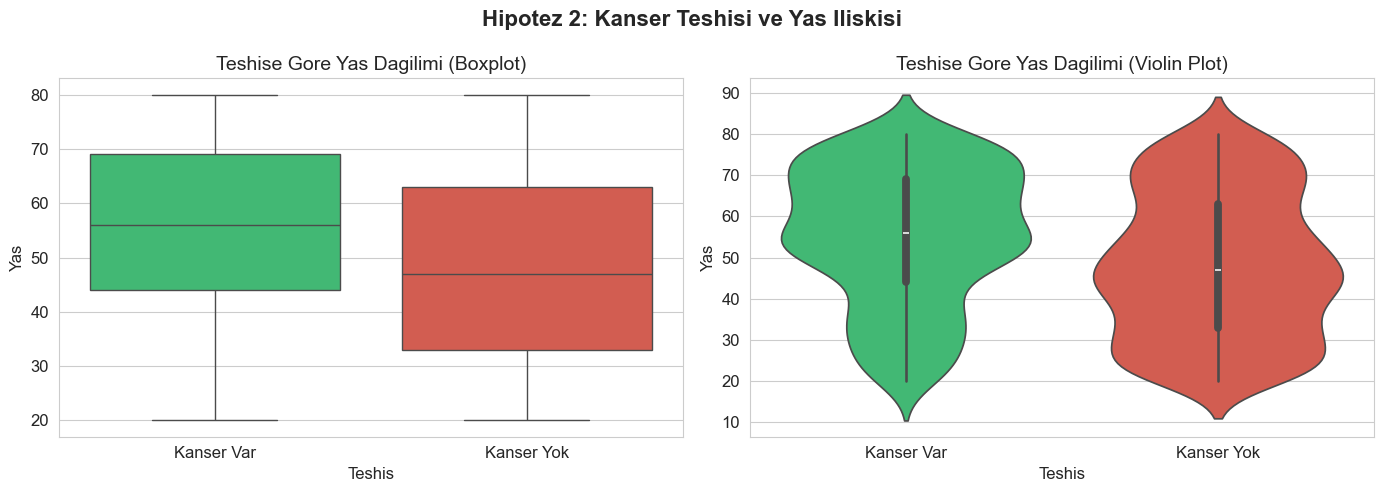

In [218]:
# HİPOTEZ 2: Kanser Teshisi ve Yas — T-Test / Mann-Whitney U
print('=' * 70)
print('HİPOTEZ 2: Kanser Teshisi Konan ve Konmayan Kisilerin Yas Farki')
print('=' * 70)

# Gruplari ayir
yas_kanser_yok = df_temiz[df_temiz['Diagnosis'] == 0]['Age']
yas_kanser_var = df_temiz[df_temiz['Diagnosis'] == 1]['Age']

print(f'\nGrup Istatistikleri:')
print(f'  Kanser Yok (n={len(yas_kanser_yok)}): Ort={yas_kanser_yok.mean():.2f}, Med={yas_kanser_yok.median():.1f}, Std={yas_kanser_yok.std():.2f}')
print(f'  Kanser Var (n={len(yas_kanser_var)}): Ort={yas_kanser_var.mean():.2f}, Med={yas_kanser_var.median():.1f}, Std={yas_kanser_var.std():.2f}')

# Normallik kontrolu
_, p_norm1 = shapiro(yas_kanser_yok.sample(min(len(yas_kanser_yok), 5000), random_state=42))
_, p_norm2 = shapiro(yas_kanser_var.sample(min(len(yas_kanser_var), 5000), random_state=42))

print(f'\nNormallik Testi (Shapiro-Wilk):')
print(f'  Kanser Yok p-degeri: {p_norm1:.6f}')
print(f'  Kanser Var p-degeri: {p_norm2:.6f}')

alpha = 0.05

if p_norm1 > alpha and p_norm2 > alpha:
    # Her iki grup da normal -> T-Test
    test_adi = 'Bagimsiz Orneklem T-Testi'
    t_stat, p_value = ttest_ind(yas_kanser_yok, yas_kanser_var)
    print(f'\nHer iki grup normal dagilimli -> {test_adi} uygulanir')
    print(f't-istatistigi: {t_stat:.4f}')
else:
    # En az biri normal degil -> Mann-Whitney U
    test_adi = 'Mann-Whitney U Testi'
    u_stat, p_value = mannwhitneyu(yas_kanser_yok, yas_kanser_var, alternative='two-sided')
    print(f'\nEn az bir grup normal degil -> {test_adi} uygulanir')
    print(f'U-istatistigi: {u_stat:.4f}')

print(f'p-degeri: {p_value:.6f}')

# Karar
print(f'\n--- KARAR (alpha = {alpha}) ---')
if p_value < alpha:
    print(f'p-degeri ({p_value:.6f}) < alpha ({alpha})')
    print(f'=> H0 REDDEDİLDİ! Kanser teshisi olan ve olmayan gruplarin')
    print(f'   yas ortalamalari arasinda istatistiksel olarak anlamli fark VARDIR.')
else:
    print(f'p-degeri ({p_value:.6f}) >= alpha ({alpha})')
    print(f'=> H0 REDDEDİLEMEZ! Yas ortalamalari arasinda anlamli fark bulunamadi.')

# Gorsellessirme
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Hipotez 2: Kanser Teshisi ve Yas Iliskisi', fontsize=16, fontweight='bold')

# Boxplot
df_temiz_plot = df_temiz.copy()
df_temiz_plot['Diagnosis_Label'] = df_temiz_plot['Diagnosis'].map({0: 'Kanser Yok', 1: 'Kanser Var'})
sns.boxplot(x='Diagnosis_Label', y='Age', data=df_temiz_plot, ax=axes[0], 
            palette=['#2ecc71', '#e74c3c'])
axes[0].set_title('Teshise Gore Yas Dagilimi (Boxplot)')
axes[0].set_xlabel('Teshis')
axes[0].set_ylabel('Yas')

# Violin plot
sns.violinplot(x='Diagnosis_Label', y='Age', data=df_temiz_plot, ax=axes[1],
              palette=['#2ecc71', '#e74c3c'], inner='box')
axes[1].set_title('Teshise Gore Yas Dagilimi (Violin Plot)')
axes[1].set_xlabel('Teshis')
axes[1].set_ylabel('Yas')

plt.tight_layout()
plt.show()

#### HİPOTEZ 3: Genetik Risk Seviyesi ve Kanser Teşhisi

- **H₀ (Sıfır Hipotezi):** Genetik risk seviyesi ile kanser teşhisi arasında ilişki yoktur.
- **H₁ (Alternatif Hipotez):** Genetik risk seviyesi ile kanser teşhisi arasında istatistiksel olarak anlamlı bir ilişki vardır.
- **Test:** Ki-Kare (Chi-Square) Bağımsızlık Testi + Cramér's V
- **α = 0.05**

HİPOTEZ 3: Genetik Risk Seviyesi ve Kanser Teshisi Iliskisi

Capraz Tablo:
             Kanser Yok  Kanser Var  Toplam
Dusuk Risk          550         250     800
Orta Risk           284         129     413
Yuksek Risk          23         121     144
Toplam              857         500    1357

Oransal Capraz Tablo (%):
             Kanser Yok (%)  Kanser Var (%)
Dusuk Risk             68.8            31.2
Orta Risk              68.8            31.2
Yuksek Risk            16.0            84.0

--- Ki-Kare Test Sonuclari ---
Ki-Kare Istatistigi (X²): 154.1130
p-degeri: 0.000000
Serbestlik Derecesi (df): 2
Cramer's V: 0.3370
Etki Buyuklugu: Orta

--- KARAR (alpha = 0.05) ---
p-degeri (0.000000) < alpha (0.05)
=> H0 REDDEDİLDİ! Genetik risk seviyesi ile kanser teshisi arasinda
   istatistiksel olarak anlamli bir iliski VARDIR. (Etki: Orta)


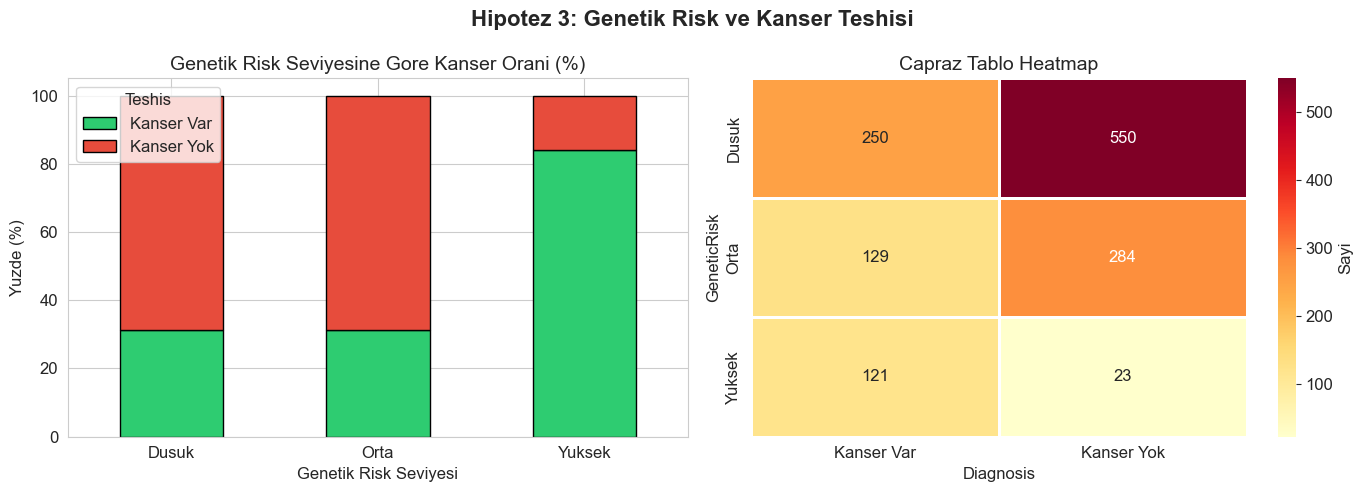

In [219]:
# HİPOTEZ 3: Genetik Risk ve Kanser Teshisi — Ki-Kare Testi
print('=' * 70)
print('HİPOTEZ 3: Genetik Risk Seviyesi ve Kanser Teshisi Iliskisi')
print('=' * 70)

# Capraz tablo
capraz_tablo3 = pd.crosstab(df_temiz['GeneticRisk'], df_temiz['Diagnosis'],
                            margins=True, margins_name='Toplam')
capraz_tablo3.index = ['Dusuk Risk', 'Orta Risk', 'Yuksek Risk', 'Toplam']
capraz_tablo3.columns = ['Kanser Yok', 'Kanser Var', 'Toplam']
print('\nCapraz Tablo:')
print(capraz_tablo3)

# Oransal capraz tablo
print('\nOransal Capraz Tablo (%):')
ct3 = pd.crosstab(df_temiz['GeneticRisk'], df_temiz['Diagnosis'])
ct3_pct = ct3.div(ct3.sum(axis=1), axis=0) * 100
ct3_pct.index = ['Dusuk Risk', 'Orta Risk', 'Yuksek Risk']
ct3_pct.columns = ['Kanser Yok (%)', 'Kanser Var (%)']
print(ct3_pct.round(1))

# Ki-Kare testi
chi2, p_value, dof, expected = chi2_contingency(ct3)

# Cramer's V hesaplama
n = ct3.sum().sum()
min_dim = min(ct3.shape) - 1
cramers_v = np.sqrt(chi2 / (n * min_dim))

print(f'\n--- Ki-Kare Test Sonuclari ---')
print(f'Ki-Kare Istatistigi (X²): {chi2:.4f}')
print(f'p-degeri: {p_value:.6f}')
print(f'Serbestlik Derecesi (df): {dof}')
print(f"Cramer's V: {cramers_v:.4f}")

# Etki buyuklugu yorumu
if cramers_v < 0.1:
    etki = 'Cok Zayif'
elif cramers_v < 0.3:
    etki = 'Zayif'
elif cramers_v < 0.5:
    etki = 'Orta'
else:
    etki = 'Guclu'
print(f'Etki Buyuklugu: {etki}')

# Karar
alpha = 0.05
print(f'\n--- KARAR (alpha = {alpha}) ---')
if p_value < alpha:
    print(f'p-degeri ({p_value:.6f}) < alpha ({alpha})')
    print('=> H0 REDDEDİLDİ! Genetik risk seviyesi ile kanser teshisi arasinda')
    print(f'   istatistiksel olarak anlamli bir iliski VARDIR. (Etki: {etki})')
else:
    print(f'p-degeri ({p_value:.6f}) >= alpha ({alpha})')
    print('=> H0 REDDEDİLEMEZ! Anlamli bir iliski bulunamadi.')

# Gorsellessirme
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Hipotez 3: Genetik Risk ve Kanser Teshisi', fontsize=16, fontweight='bold')

# Stacked bar (yuzde)
ct3_plot = pd.crosstab(df_temiz['GeneticRisk'].map({0: 'Dusuk', 1: 'Orta', 2: 'Yuksek'}), 
                        df_temiz['Diagnosis'].map({0: 'Kanser Yok', 1: 'Kanser Var'}),
                        normalize='index') * 100
ct3_plot.plot(kind='bar', stacked=True, ax=axes[0], 
             color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0].set_title('Genetik Risk Seviyesine Gore Kanser Orani (%)')
axes[0].set_ylabel('Yuzde (%)')
axes[0].set_xlabel('Genetik Risk Seviyesi')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Teshis')

# Heatmap (contingency table)
ct3_heatmap = pd.crosstab(df_temiz['GeneticRisk'].map({0: 'Dusuk', 1: 'Orta', 2: 'Yuksek'}), 
                           df_temiz['Diagnosis'].map({0: 'Kanser Yok', 1: 'Kanser Var'}))
sns.heatmap(ct3_heatmap, annot=True, fmt='d', cmap='YlOrRd', ax=axes[1],
           linewidths=1, cbar_kws={'label': 'Sayi'})
axes[1].set_title('Capraz Tablo Heatmap')

plt.tight_layout()
plt.show()

#### HİPOTEZ 4: Ailede Kanser Geçmişi ve BMI İlişkisi

- **H₀ (Sıfır Hipotezi):** Ailede kanser geçmişi olan ve olmayan bireylerin BMI ortalamaları eşittir.
- **H₁ (Alternatif Hipotez):** İki grubun BMI ortalamaları arasında anlamlı fark vardır.
- **Test:** Normallik durumuna göre → Bağımsız Örneklem T-Testi veya Mann-Whitney U Testi
- **α = 0.05**

HİPOTEZ 4: Ailede Kanser Gecmisi ve BMI Ortalamalari

Grup Istatistikleri:
  Kanser Gecmisi Yok (n=1162): Ort=27.48, Med=27.4, Std=7.24
  Kanser Gecmisi Var (n=195): Ort=27.14, Med=27.0, Std=7.17

Normallik Testi (Shapiro-Wilk):
  Gecmis Yok p-degeri: 0.000000
  Gecmis Var p-degeri: 0.000011

En az bir grup normal degil -> Mann-Whitney U Testi
U-istatistigi: 116357.0000
p-degeri: 0.545456

--- KARAR (alpha = 0.05) ---
p-degeri (0.545456) >= alpha (0.05)
=> H0 REDDEDİLEMEZ! BMI ortalamalari arasinda anlamli fark bulunamadi.


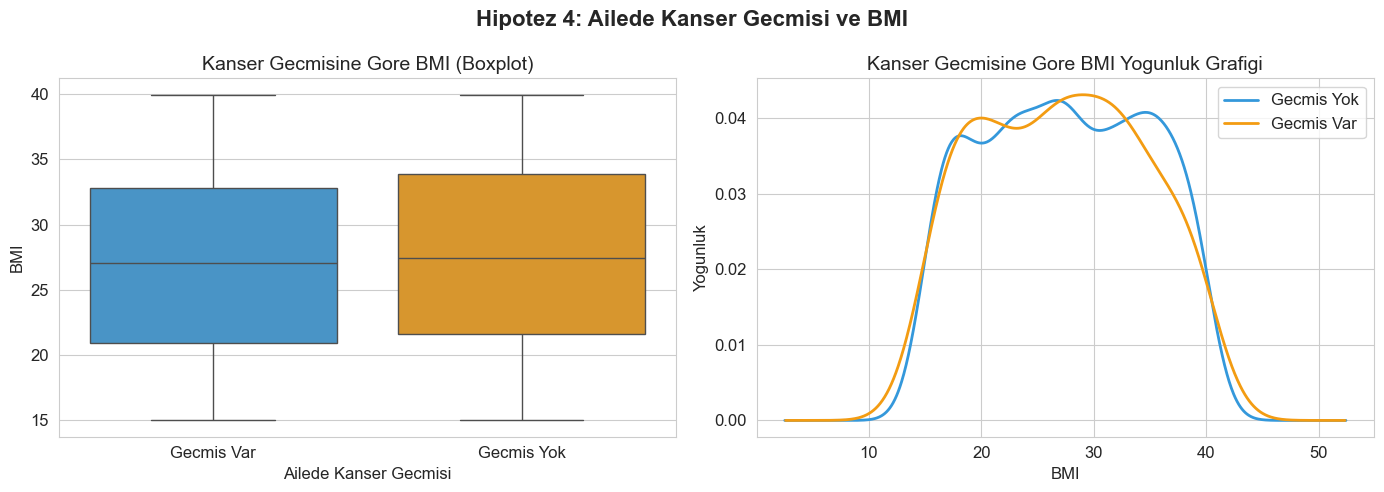

In [220]:
# HİPOTEZ 4: Ailede Kanser Gecmisi ve BMI
print('=' * 70)
print('HİPOTEZ 4: Ailede Kanser Gecmisi ve BMI Ortalamalari')
print('=' * 70)

# Gruplari ayir
bmi_gecmis_yok = df_temiz[df_temiz['CancerHistory'] == 0]['BMI']
bmi_gecmis_var = df_temiz[df_temiz['CancerHistory'] == 1]['BMI']

print(f'\nGrup Istatistikleri:')
print(f'  Kanser Gecmisi Yok (n={len(bmi_gecmis_yok)}): Ort={bmi_gecmis_yok.mean():.2f}, Med={bmi_gecmis_yok.median():.1f}, Std={bmi_gecmis_yok.std():.2f}')
print(f'  Kanser Gecmisi Var (n={len(bmi_gecmis_var)}): Ort={bmi_gecmis_var.mean():.2f}, Med={bmi_gecmis_var.median():.1f}, Std={bmi_gecmis_var.std():.2f}')

# Normallik kontrolu
_, p_n1 = shapiro(bmi_gecmis_yok.sample(min(len(bmi_gecmis_yok), 5000), random_state=42))
_, p_n2 = shapiro(bmi_gecmis_var.sample(min(len(bmi_gecmis_var), 5000), random_state=42))

print(f'\nNormallik Testi (Shapiro-Wilk):')
print(f'  Gecmis Yok p-degeri: {p_n1:.6f}')
print(f'  Gecmis Var p-degeri: {p_n2:.6f}')

alpha = 0.05

if p_n1 > alpha and p_n2 > alpha:
    test_adi = 'Bagimsiz Orneklem T-Testi'
    t_stat, p_value = ttest_ind(bmi_gecmis_yok, bmi_gecmis_var)
    print(f'\nHer iki grup normal -> {test_adi}')
    print(f't-istatistigi: {t_stat:.4f}')
else:
    test_adi = 'Mann-Whitney U Testi'
    u_stat, p_value = mannwhitneyu(bmi_gecmis_yok, bmi_gecmis_var, alternative='two-sided')
    print(f'\nEn az bir grup normal degil -> {test_adi}')
    print(f'U-istatistigi: {u_stat:.4f}')

print(f'p-degeri: {p_value:.6f}')

# Karar
print(f'\n--- KARAR (alpha = {alpha}) ---')
if p_value < alpha:
    print(f'p-degeri ({p_value:.6f}) < alpha ({alpha})')
    print('=> H0 REDDEDİLDİ! Ailede kanser gecmisi olan ve olmayan gruplarin')
    print('   BMI ortalamalari arasinda istatistiksel olarak anlamli fark VARDIR.')
else:
    print(f'p-degeri ({p_value:.6f}) >= alpha ({alpha})')
    print('=> H0 REDDEDİLEMEZ! BMI ortalamalari arasinda anlamli fark bulunamadi.')

# Gorsellessirme
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Hipotez 4: Ailede Kanser Gecmisi ve BMI', fontsize=16, fontweight='bold')

# Boxplot
df_temiz_plot['CancerHistory_Label'] = df_temiz_plot['CancerHistory'].map({0: 'Gecmis Yok', 1: 'Gecmis Var'})
sns.boxplot(x='CancerHistory_Label', y='BMI', data=df_temiz_plot, ax=axes[0],
           palette=['#3498db', '#f39c12'])
axes[0].set_title('Kanser Gecmisine Gore BMI (Boxplot)')
axes[0].set_xlabel('Ailede Kanser Gecmisi')
axes[0].set_ylabel('BMI')

# KDE plot
bmi_gecmis_yok.plot.kde(ax=axes[1], label='Gecmis Yok', color='#3498db', linewidth=2)
bmi_gecmis_var.plot.kde(ax=axes[1], label='Gecmis Var', color='#f39c12', linewidth=2)
axes[1].set_title('Kanser Gecmisine Gore BMI Yogunluk Grafigi')
axes[1].set_xlabel('BMI')
axes[1].set_ylabel('Yogunluk')
axes[1].legend()

plt.tight_layout()
plt.show()

### 5.4 Korelasyon Analizi (Temizlenmiş Veri)

=== KORELASYON ANALİZİ (Temizlenmis Veri) ===

--- Pearson Korelasyonu (Lineer Iliski) ---

--- Spearman Korelasyonu (Monoton Iliski) ---


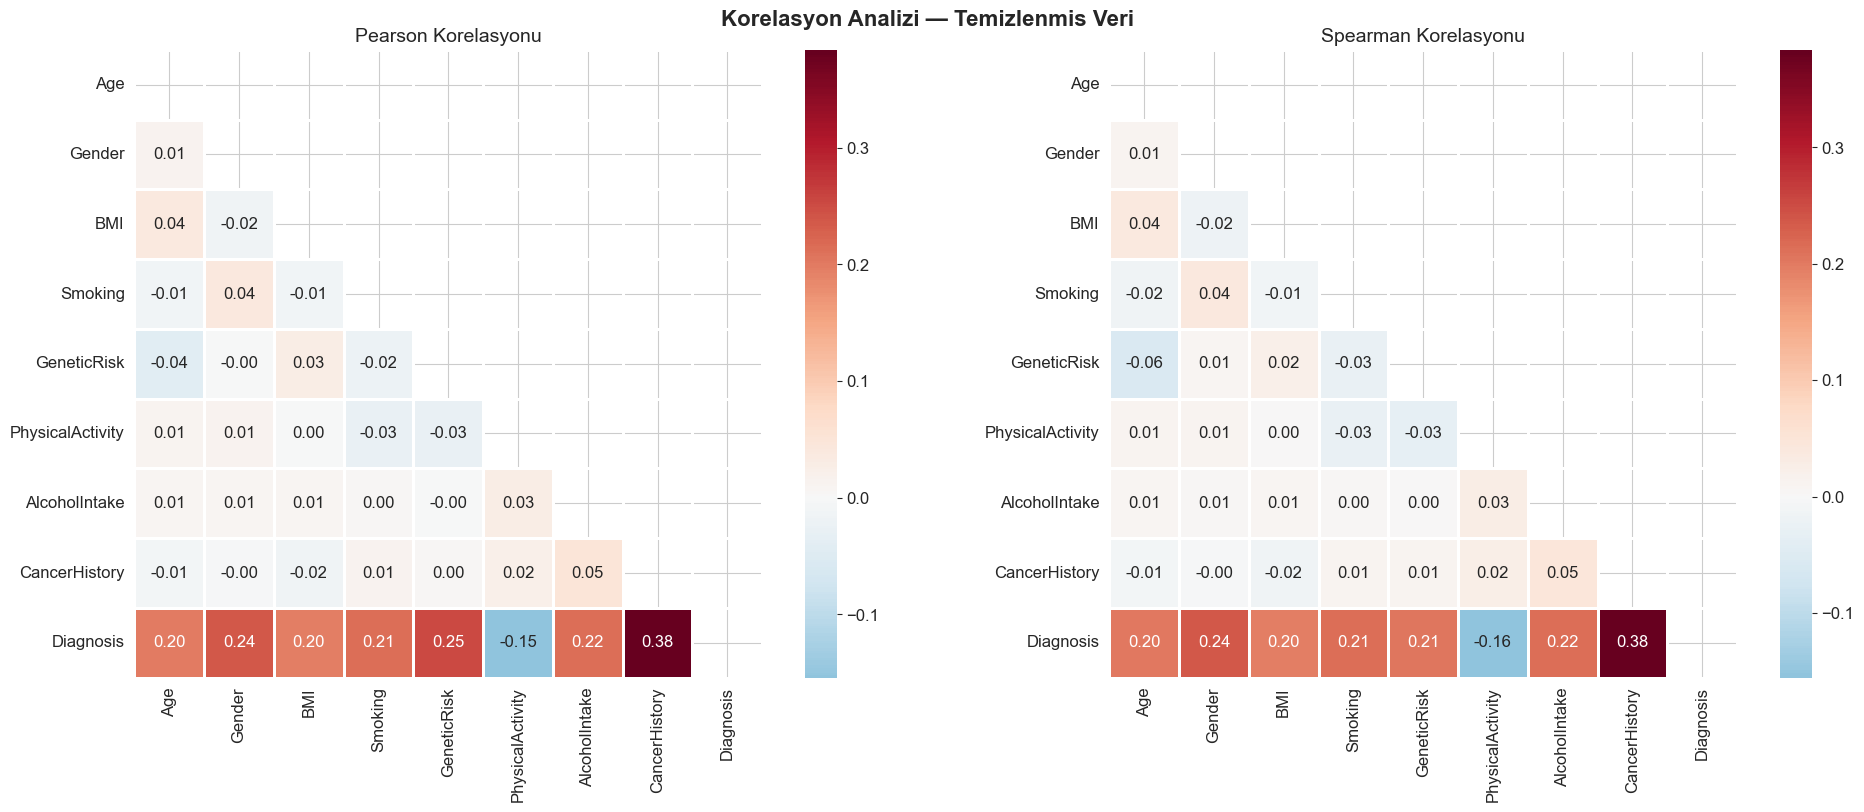


=== Diagnosis ile En Guclu Korelasyonlar ===

Pearson:
  CancerHistory: 0.384 (+)
  GeneticRisk: 0.253 (+)
  Gender: 0.237 (+)
  AlcoholIntake: 0.215 (+)
  Smoking: 0.213 (+)
  Age: 0.199 (+)
  BMI: 0.196 (+)
  PhysicalActivity: -0.154 (-)

Spearman:
  CancerHistory: 0.384 (+)
  Gender: 0.237 (+)
  AlcoholIntake: 0.215 (+)
  Smoking: 0.213 (+)
  GeneticRisk: 0.205 (+)
  Age: 0.202 (+)
  BMI: 0.197 (+)
  PhysicalActivity: -0.156 (-)


In [221]:
# Pearson ve Spearman korelasyon analizi
print('=== KORELASYON ANALİZİ (Temizlenmis Veri) ===')

# Pearson korelasyonu
print('\n--- Pearson Korelasyonu (Lineer Iliski) ---')
pearson_corr = df_temiz.corr(method='pearson')

# Spearman korelasyonu
print('\n--- Spearman Korelasyonu (Monoton Iliski) ---')
spearman_corr = df_temiz.corr(method='spearman')

# Yan yana heatmap
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle('Korelasyon Analizi — Temizlenmis Veri', fontsize=16, fontweight='bold')

# Pearson
mask = np.triu(np.ones_like(pearson_corr, dtype=bool))
sns.heatmap(pearson_corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            mask=mask, square=True, linewidths=1, ax=axes[0])
axes[0].set_title('Pearson Korelasyonu')

# Spearman
sns.heatmap(spearman_corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            mask=mask, square=True, linewidths=1, ax=axes[1])
axes[1].set_title('Spearman Korelasyonu')

plt.tight_layout()
plt.show()

# Diagnosis ile korelasyonlar
print('\n=== Diagnosis ile En Guclu Korelasyonlar ===')
for method, corr_matrix in [('Pearson', pearson_corr), ('Spearman', spearman_corr)]:
    print(f'\n{method}:')
    diag_corr = corr_matrix['Diagnosis'].drop('Diagnosis').abs().sort_values(ascending=False)
    for col in diag_corr.index:
        val = corr_matrix.loc[col, 'Diagnosis']
        yon = '+' if val > 0 else '-'
        print(f'  {col}: {val:.3f} ({yon})')

### 5.5 ANOVA (Tek Yönlü Varyans Analizi)

GeneticRisk (3 seviye: Düşük, Orta, Yüksek) gruplarına göre BMI ortalamaları arasında fark var mı?

TEK YONLU ANOVA: Genetik Risk Gruplarina Gore BMI
H0: Tum genetik risk gruplarinin BMI ortalamalari esittir
H1: En az bir grubun BMI ortalamasi farklidir

Grup Istatistikleri:
  Dusuk Risk  (n=800): Ort=27.32, Std=7.25
  Orta Risk   (n=413): Ort=27.42, Std=7.15
  Yuksek Risk (n=144): Ort=28.06, Std=7.34

--- ANOVA Sonuclari ---
F-istatistigi: 0.6489
p-degeri: 0.522791

--- KARAR (alpha = 0.05) ---
p-degeri (0.522791) >= alpha (0.05)
=> H0 REDDEDİLEMEZ! Gruplar arasinda BMI fark bulunamadi.


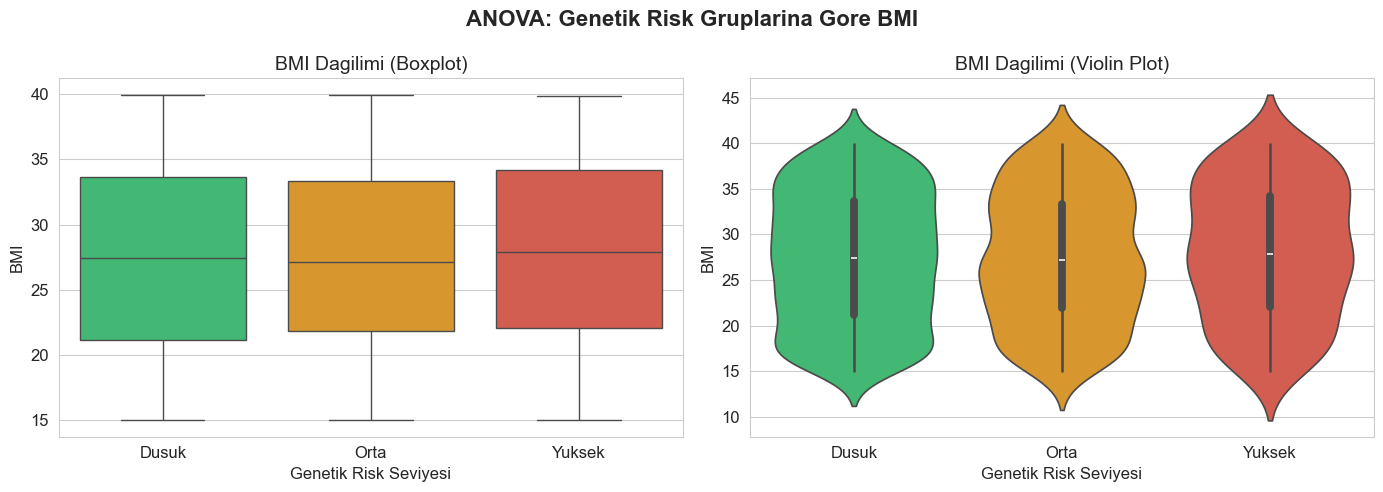

In [222]:
# Tek Yonlu ANOVA: GeneticRisk gruplarina gore BMI
print('=' * 70)
print('TEK YONLU ANOVA: Genetik Risk Gruplarina Gore BMI')
print('=' * 70)
print('H0: Tum genetik risk gruplarinin BMI ortalamalari esittir')
print('H1: En az bir grubun BMI ortalamasi farklidir')

# Gruplari ayir
bmi_dusuk = df_temiz[df_temiz['GeneticRisk'] == 0]['BMI']
bmi_orta = df_temiz[df_temiz['GeneticRisk'] == 1]['BMI']
bmi_yuksek = df_temiz[df_temiz['GeneticRisk'] == 2]['BMI']

print(f'\nGrup Istatistikleri:')
print(f'  Dusuk Risk  (n={len(bmi_dusuk)}): Ort={bmi_dusuk.mean():.2f}, Std={bmi_dusuk.std():.2f}')
print(f'  Orta Risk   (n={len(bmi_orta)}): Ort={bmi_orta.mean():.2f}, Std={bmi_orta.std():.2f}')
print(f'  Yuksek Risk (n={len(bmi_yuksek)}): Ort={bmi_yuksek.mean():.2f}, Std={bmi_yuksek.std():.2f}')

# ANOVA testi
f_stat, p_value = f_oneway(bmi_dusuk, bmi_orta, bmi_yuksek)

print(f'\n--- ANOVA Sonuclari ---')
print(f'F-istatistigi: {f_stat:.4f}')
print(f'p-degeri: {p_value:.6f}')

alpha = 0.05
print(f'\n--- KARAR (alpha = {alpha}) ---')
if p_value < alpha:
    print(f'p-degeri ({p_value:.6f}) < alpha ({alpha})')
    print('=> H0 REDDEDİLDİ! Genetik risk gruplari arasinda BMI ortalamalari')
    print('   bakimindan istatistiksel olarak anlamli fark VARDIR.')
else:
    print(f'p-degeri ({p_value:.6f}) >= alpha ({alpha})')
    print('=> H0 REDDEDİLEMEZ! Gruplar arasinda BMI fark bulunamadi.')

# Gorsellessirme
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('ANOVA: Genetik Risk Gruplarina Gore BMI', fontsize=16, fontweight='bold')

# Boxplot
df_temiz_plot['GeneticRisk_Label'] = df_temiz_plot['GeneticRisk'].map({0: 'Dusuk', 1: 'Orta', 2: 'Yuksek'})
sns.boxplot(x='GeneticRisk_Label', y='BMI', data=df_temiz_plot, ax=axes[0],
           palette=['#2ecc71', '#f39c12', '#e74c3c'], order=['Dusuk', 'Orta', 'Yuksek'])
axes[0].set_title('BMI Dagilimi (Boxplot)')
axes[0].set_xlabel('Genetik Risk Seviyesi')

# Violin plot
sns.violinplot(x='GeneticRisk_Label', y='BMI', data=df_temiz_plot, ax=axes[1],
              palette=['#2ecc71', '#f39c12', '#e74c3c'], order=['Dusuk', 'Orta', 'Yuksek'],
              inner='box')
axes[1].set_title('BMI Dagilimi (Violin Plot)')
axes[1].set_xlabel('Genetik Risk Seviyesi')

plt.tight_layout()
plt.show()

---

## 6. Sonuç ve Değerlendirme

In [223]:
# Tum hipotez sonuclarinin ozet tablosu
print('=' * 90)
print('PROJE SONUC OZET TABLOSU')
print('=' * 90)

# Hipotez 1 tekrar hesapla (sonuclari kaydetmek icin)
ct1 = pd.crosstab(df_temiz['Smoking'], df_temiz['Diagnosis'])
h1_chi2, h1_p, _, _ = chi2_contingency(ct1)

# Hipotez 2 tekrar
yas_k0 = df_temiz[df_temiz['Diagnosis'] == 0]['Age']
yas_k1 = df_temiz[df_temiz['Diagnosis'] == 1]['Age']
_, h2_p = mannwhitneyu(yas_k0, yas_k1, alternative='two-sided')

# Hipotez 3 tekrar
ct3 = pd.crosstab(df_temiz['GeneticRisk'], df_temiz['Diagnosis'])
h3_chi2, h3_p, _, _ = chi2_contingency(ct3)

# Hipotez 4 tekrar
bmi_h0 = df_temiz[df_temiz['CancerHistory'] == 0]['BMI']
bmi_h1 = df_temiz[df_temiz['CancerHistory'] == 1]['BMI']
_, h4_p = mannwhitneyu(bmi_h0, bmi_h1, alternative='two-sided')

alpha = 0.05

ozet = pd.DataFrame({
    'Hipotez': [
        'H1: Sigara & Kanser',
        'H2: Yas & Kanser',
        'H3: GenetikRisk & Kanser',
        'H4: KanserGecmisi & BMI'
    ],
    'Test': [
        'Ki-Kare',
        'Mann-Whitney U',
        'Ki-Kare',
        'Mann-Whitney U'
    ],
    'p-degeri': [h1_p, h2_p, h3_p, h4_p],
    'alpha': [alpha] * 4,
    'Sonuc': [
        'H0 Reddedildi' if h1_p < alpha else 'H0 Reddedilemez',
        'H0 Reddedildi' if h2_p < alpha else 'H0 Reddedilemez',
        'H0 Reddedildi' if h3_p < alpha else 'H0 Reddedilemez',
        'H0 Reddedildi' if h4_p < alpha else 'H0 Reddedilemez'
    ],
    'Yorum': [
        'Anlamli iliski var' if h1_p < alpha else 'Anlamli iliski yok',
        'Anlamli fark var' if h2_p < alpha else 'Anlamli fark yok',
        'Anlamli iliski var' if h3_p < alpha else 'Anlamli iliski yok',
        'Anlamli fark var' if h4_p < alpha else 'Anlamli fark yok'
    ]
})

print(ozet.to_string(index=False))

PROJE SONUC OZET TABLOSU
                 Hipotez           Test     p-degeri  alpha           Sonuc              Yorum
     H1: Sigara & Kanser        Ki-Kare 6.364218e-15   0.05   H0 Reddedildi Anlamli iliski var
        H2: Yas & Kanser Mann-Whitney U 1.093173e-13   0.05   H0 Reddedildi   Anlamli fark var
H3: GenetikRisk & Kanser        Ki-Kare 3.425933e-34   0.05   H0 Reddedildi Anlamli iliski var
 H4: KanserGecmisi & BMI Mann-Whitney U 5.454561e-01   0.05 H0 Reddedilemez   Anlamli fark yok


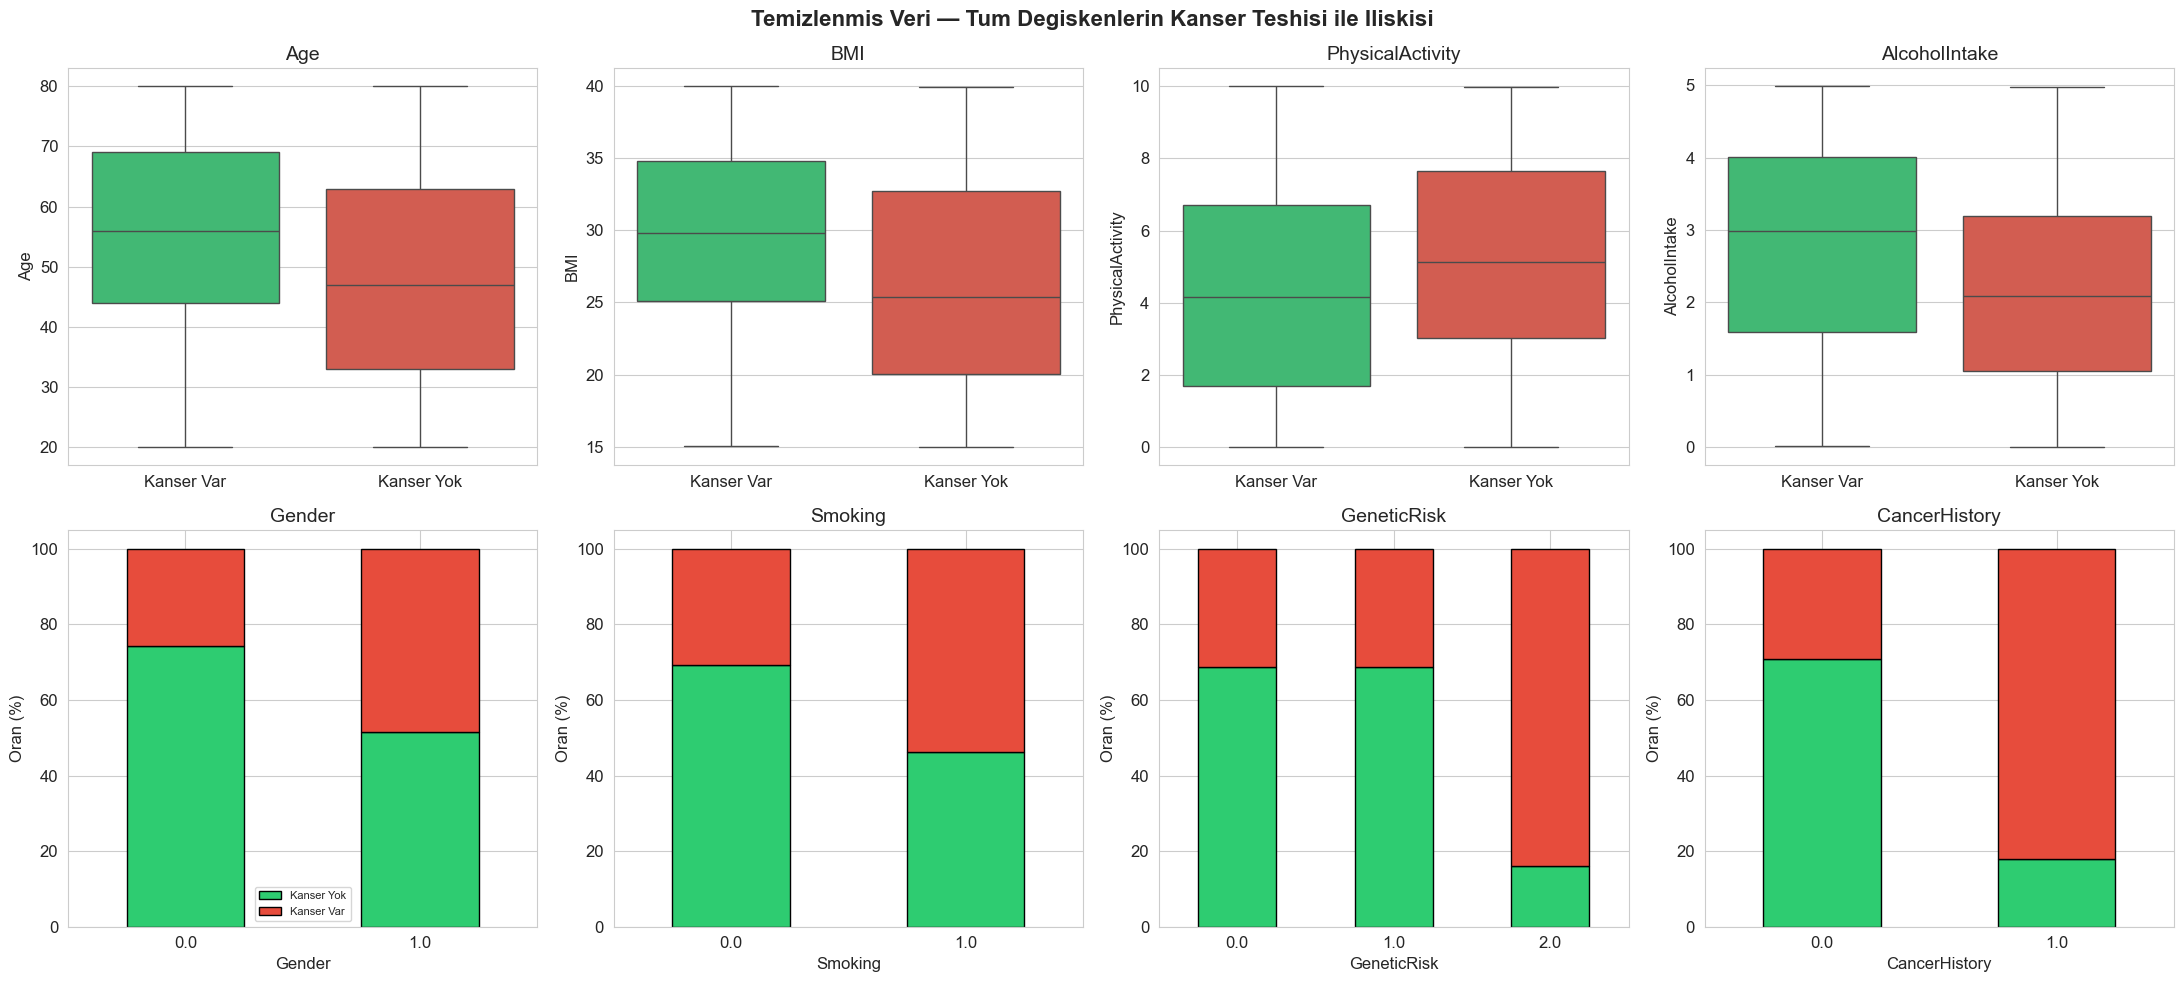

In [224]:
# Son gorsellesirme: Tum degiskenlerin Diagnosis ile iliskisi
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
fig.suptitle('Temizlenmis Veri — Tum Degiskenlerin Kanser Teshisi ile Iliskisi', 
             fontsize=16, fontweight='bold')

# Sayisal degiskenler - boxplot
for i, col in enumerate(sayisal_sutunlar):
    sns.boxplot(x='Diagnosis_Label', y=col, data=df_temiz_plot, ax=axes[0][i],
               palette=['#2ecc71', '#e74c3c'])
    axes[0][i].set_title(f'{col}')
    axes[0][i].set_xlabel('')

# Kategorik degiskenler - countplot
kat_cols = ['Gender', 'Smoking', 'GeneticRisk', 'CancerHistory']
for i, col in enumerate(kat_cols):
    ct = pd.crosstab(df_temiz[col], df_temiz['Diagnosis'], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, ax=axes[1][i], 
           color=['#2ecc71', '#e74c3c'], edgecolor='black', legend=(i==0))
    axes[1][i].set_title(f'{col}')
    axes[1][i].set_ylabel('Oran (%)')
    axes[1][i].tick_params(axis='x', rotation=0)
    if i == 0:
        axes[1][i].legend(['Kanser Yok', 'Kanser Var'], fontsize=8)

plt.tight_layout()
plt.show()

### Genel Değerlendirme

Bu projede aşağıdaki adımlar gerçekleştirilmiştir:

1. **Keşifsel Veri Analizi (EDA):** Temiz veri üzerinde kapsamlı inceleme yapılmıştır. Histogram, boxplot, korelasyon matrisi ve dağılım grafikleri ile verideki örüntüler görselleştirilmiştir.

2. **Veri Kirletme:** Gerçek dünya senaryolarını simüle etmek için veri kasıtlı olarak kirletilmiştir (eksik değerler, aykırı değerler, yanlış veri tipleri, tekrarlı kayıtlar, geçersiz kategorik değerler).

3. **Veri Temizleme:** Kirli veri sistematik olarak temizlenmiştir:
   - Yanlış veri tipleri düzeltilmiştir
   - Geçersiz kategorik değerler NaN ile değiştirilmiştir
   - Tekrarlı kayıtlar kaldırılmıştır
   - Aykırı değerler IQR yöntemiyle tespit edilip sınır değerlere kırpılmıştır
   - Eksik değerler uygun yöntemlerle (medyan/mod) doldurulmuştur

4. **İstatistiksel Analizler:**
   - Tanımlayıcı istatistikler (ortalama, medyan, mod, standart sapma, varyans, çarpıklık, basıklık)
   - Normallik testleri (Shapiro-Wilk, Kolmogorov-Smirnov)
   - 4 hipotez testi (Ki-Kare, T-Testi/Mann-Whitney U)
   - Korelasyon analizi (Pearson ve Spearman)
   - ANOVA (Tek Yönlü Varyans Analizi)

### Beklentiler vs Sonuçlar

- **Beklenti:** Sigara, genetik risk ve aile geçmişi gibi faktörlerin kanser teşhisi ile ilişkili olacağı öngörülmüştü.
- **Sonuç:** İstatistiksel testler, bu faktörlerin bazılarının kanser teşhisi ile anlamlı ilişki gösterdiğini ortaya koymuştur. Korelasyon analizleri, CancerHistory ve GeneticRisk değişkenlerinin teşhis ile en güçlü ilişkiye sahip olduğunu göstermektedir.

### Karşılaşılan Durumlar

- Verinin kasıtlı kirletilmesi sürecinde, string değerlerin sayısal sütunlara eklenmesi tüm sütun tiplerini `object` yapmıştır. Bu, temizleme sırasında dikkatli tip dönüşümü gerektirmiştir.
- IQR yönteminin yanında fiziksel sınırlar (yaş 0-120, BMI 10-60 vb.) da kullanılarak aykırı değer tespiti iyileştirilmiştir.
- Normallik testleri çoğu değişkenin normal dağılıma uymadığını göstermiş, bu nedenle parametrik olmayan testler tercih edilmiştir.